In [1]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor")
sys.path.append(str(project_path))

In [2]:
import tensorflow as tf
import torch

print("TensorFlow version:", tf.__version__)
print("TensorFlow GPUs:", tf.config.list_physical_devices("GPU"))

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("PyTorch GPU:", torch.cuda.get_device_name(0))

TensorFlow version: 2.20.0
TensorFlow GPUs: []
PyTorch version: 2.11.0+cpu
PyTorch CUDA available: False


### Imports

In [3]:
from data_exploration.utils.data_loader import DataLoader
from data_exploration.utils.data_explorer import DataExplorer
from second_term_gpa_regression.utils.data_cleaner_v1 import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TerminateOnNaN
import keras
import tensorflow as tf
from keras_tuner import Hyperband
import shutil
import time

from tensorflow.keras.optimizers import Adam, SGD, RMSprop


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [4]:
# # Load the original student dataset 
# data_file = project_path / "data/Student data.csv"
# dl = DataLoader(str(data_file))
# structure_df = dl.load_and_clean_data()
# structure_df.columns.to_list()

#  # Save the cleaned dataset structure to a new CSV file
# structure_df.to_csv(project_path / "data/structured_student_data.csv", index=False)

In [5]:
# ------ Helper Classes for Custom Metrics ------
class RMSEMetric(tf.keras.metrics.Metric):
    """Dataset-level RMSE accumulated across batches."""

    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        squared_errors = tf.square(y_true - y_pred)
        self.sse.assign_add(tf.reduce_sum(squared_errors))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        return tf.sqrt(tf.math.divide_no_nan(self.sse, self.count))

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

class R2Metric(tf.keras.metrics.Metric):
    """Dataset-level R-squared metric accumulated across batches."""

    def __init__(self, name="r2", **kwargs):
        super().__init__(name=name, **kwargs)
        self.ss_res = self.add_weight(name="ss_res", initializer="zeros")
        self.sum_y = self.add_weight(name="sum_y", initializer="zeros")
        self.sum_y_sq = self.add_weight(name="sum_y_sq", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sum_y.assign_add(tf.reduce_sum(y_true))
        self.sum_y_sq.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        ss_tot = self.sum_y_sq - tf.square(self.sum_y) / (self.count + tf.keras.backend.epsilon())
        return 1.0 - tf.math.divide_no_nan(self.ss_res, ss_tot + tf.keras.backend.epsilon())

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

In [6]:
# ----- Helper Functions -----
def print_header(name):
    """Print a compact section header."""
    print("\n" + f" {name} ".center(72, "=") + "\n")


def custom_callback(monitor, mode, patience, filepath):
    """Early stopping and model checkpoint callbacks for training."""
    es = EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True, verbose=1, mode=mode)
    mc = ModelCheckpoint(filepath=filepath, monitor=monitor, verbose=1, save_best_only=True, mode=mode)
    return es, mc


def get_target_scale(scaler_obj=None):
    scaler_obj = scaler_obj or globals().get('scaler', None)
    if scaler_obj is None or not hasattr(scaler_obj, 'data_min_') or not hasattr(scaler_obj, 'data_max_'):
        return 1.0
    return float(np.asarray(scaler_obj.data_max_ - scaler_obj.data_min_).ravel()[0])


def plot_regression_history(history, title_prefix='Model', scaler_obj=None):
    target_scale = get_target_scale(scaler_obj)
    mse_scale = target_scale ** 2

    train_mae = np.asarray(history.history['mae']) * target_scale
    val_mae = np.asarray(history.history['val_mae']) * target_scale
    train_loss = np.asarray(history.history['loss']) * mse_scale
    val_loss = np.asarray(history.history['val_loss']) * mse_scale

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(train_mae, label='Train MAE')
    axes[0].plot(val_mae, label='Val MAE')
    axes[0].set(title=f'{title_prefix} MAE', xlabel='Epoch', ylabel='MAE (GPA)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_loss, label='Train Loss')
    axes[1].plot(val_loss, label='Val Loss')
    if 'rmse' in history.history:
        axes[1].plot(np.asarray(history.history['rmse']) * target_scale, '--', label='Train RMSE')
        axes[1].plot(np.asarray(history.history['val_rmse']) * target_scale, '--', label='Val RMSE')
    axes[1].set(title=f'{title_prefix} Loss & RMSE', xlabel='Epoch', ylabel='Value (GPA / GPA²)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if 'r2' in history.history:
        axes[2].plot(history.history['r2'], label='Train R² (Scaled y)')
        axes[2].plot(history.history['val_r2'], label='Val R² (Scaled y)')
        axes[2].set(title=f'{title_prefix} R² (Scaled y)', xlabel='Epoch', ylabel='R²')
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best = int(np.argmin(history.history['val_loss']))
    get = lambda values: f"{np.asarray(values)[best]:.4f}"

    print(f"\nBest Epoch: {best + 1}")
    print('-' * 40)
    print(f"MAE (GPA)   -> Train: {get(train_mae)} | Val: {get(val_mae)}")
    if 'rmse' in history.history:
        print(f"RMSE (GPA)  -> Train: {get(np.asarray(history.history['rmse']) * target_scale)} | Val: {get(np.asarray(history.history['val_rmse']) * target_scale)}")
    print(f"Loss (GPA²) -> Train: {get(train_loss)} | Val: {get(val_loss)}")
    if 'r2' in history.history:
        print(f"R² (Scaled y) -> Train: {get(history.history['r2'])} | Val: {get(history.history['val_r2'])}")


def get_optimizer(name, learning_rate, clipnorm=None):
    optimizer_kwargs = {'learning_rate': learning_rate}
    if clipnorm is not None:
        optimizer_kwargs['clipnorm'] = clipnorm

    if name == 'adam':
        return Adam(**optimizer_kwargs)
    if name == 'sgd':
        return SGD(momentum=0.9, **optimizer_kwargs)
    if name == 'rmsprop':
        return RMSprop(**optimizer_kwargs)
    raise ValueError(f'Unsupported optimizer: {name}')


def build_dense_model(input_dim, layer_specs):
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])
    for spec in layer_specs:
        model.add(Dense(spec['units'], activation=spec['activation']))
        if spec.get('batch_norm', False):
            model.add(BatchNormalization())
        if spec.get('dropout', 0.0) > 0:
            model.add(Dropout(spec['dropout']))
    model.add(Dense(1))
    return model


def compile_regression_model(model, optimizer_name, learning_rate, clipnorm=None):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate, clipnorm=clipnorm),
        loss='mse',
        metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
    )
    return model


def inverse_transform_target(values, scaler):
    return scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).flatten()


def evaluate_model_original_scale(model, X_split, y_split, scaler, split_name='Split', verbose=0, print_summary=True):
    y_pred_scaled = np.asarray(model.predict(X_split, verbose=verbose)).ravel()
    y_true_scaled = np.asarray(y_split).ravel()

    if not np.isfinite(y_true_scaled).all():
        bad_count = int(np.size(y_true_scaled) - np.isfinite(y_true_scaled).sum())
        raise ValueError(f"{split_name} target contains {bad_count} non-finite value(s).")
    if not np.isfinite(y_pred_scaled).all():
        bad_count = int(np.size(y_pred_scaled) - np.isfinite(y_pred_scaled).sum())
        raise ValueError(f"{split_name} prediction contains {bad_count} non-finite value(s).")

    y_true_actual = inverse_transform_target(y_split, scaler)
    y_pred_actual = inverse_transform_target(y_pred_scaled, scaler)
    r2_original = float(r2_score(y_true_actual, y_pred_actual))
    r2_scaled = float(r2_score(y_true_scaled, y_pred_scaled))

    metrics = {
        'split': split_name,
        'rmse': float(mean_squared_error(y_true_actual, y_pred_actual) ** 0.5),
        'mse': float(mean_squared_error(y_true_actual, y_pred_actual)),
        'mae': float(mean_absolute_error(y_true_actual, y_pred_actual)),
        'r2_original': r2_original,
        'r2_scaled': r2_scaled,
    }

    if print_summary:
        print(f"{split_name} RMSE: {metrics['rmse']:.4f}")
        print(f"{split_name} MSE:  {metrics['mse']:.4f}")
        print(f"{split_name} MAE:              {metrics['mae']:.4f}")
        print(f"{split_name} R² (Original GPA): {metrics['r2_original']:.4f}")
        print(f"{split_name} R² (Scaled y):     {metrics['r2_scaled']:.4f}")

    prediction_df = pd.DataFrame({
        'Actual GPA': y_true_actual,
        'Predicted GPA': y_pred_actual,
    })
    prediction_df['Residual'] = prediction_df['Actual GPA'] - prediction_df['Predicted GPA']
    prediction_df['Absolute Error'] = prediction_df['Residual'].abs()
    prediction_df['Squared Error'] = prediction_df['Residual'] ** 2
    prediction_df = prediction_df.sort_values('Absolute Error', ascending=False).reset_index(drop=True)

    return metrics, prediction_df


def empty_regression_metrics(split_name):
    return {
        'split': split_name,
        'rmse': np.nan,
        'mse': np.nan,
        'mae': np.nan,
        'r2_original': np.nan,
        'r2_scaled': np.nan,
    }


def get_best_epoch_from_history(history, monitor='val_loss'):
    values = np.asarray(history.history.get(monitor, []), dtype=float)
    if values.size == 0:
        return None

    finite_mask = np.isfinite(values)
    if not finite_mask.any():
        return None

    safe_values = np.where(finite_mask, values, np.inf)
    return int(np.argmin(safe_values)) + 1


def get_non_finite_history_event(history):
    for metric_name, values in history.history.items():
        values_arr = np.asarray(values, dtype=float)
        non_finite_idx = np.where(~np.isfinite(values_arr))[0]
        if non_finite_idx.size:
            return int(non_finite_idx[0]) + 1, metric_name
    return None, None


def format_metrics_display(df):
    return df.rename(columns={
        'rmse': 'RMSE (GPA)',
        'mse': 'MSE (GPA²)',
        'mae': 'MAE (GPA)',
        'r2_original': 'R² (Original GPA)',
        'r2_scaled': 'R² (Scaled y)',
    })


def format_local_search_display(df):
    return df.rename(columns={
        'trial': 'Trial',
        'trial_name': 'Trial Name',
        'optimizer': 'Optimizer',
        'learning_rate': 'Learning Rate',
        'batch_size': 'Batch Size',
        'best_epoch': 'Best Epoch',
        'val_rmse': 'Val RMSE (GPA)',
        'val_mae': 'Val MAE (GPA)',
        'val_r2_original': 'Val R² (Original GPA)',
        'val_r2_scaled': 'Val R² (Scaled y)',
        'test_rmse': 'Test RMSE (GPA)',
        'test_mae': 'Test MAE (GPA)',
        'test_r2_original': 'Test R² (Original GPA)',
        'test_r2_scaled': 'Test R² (Scaled y)',
        'status': 'Status',
        'failure_reason': 'Failure Reason',
        'architecture': 'Architecture',
    })


def plot_prediction_diagnostics(prediction_df, title_prefix='Model'):
    actual = prediction_df['Actual GPA']
    predicted = prediction_df['Predicted GPA']
    residuals = prediction_df['Residual']
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(x=actual, y=predicted, color='#4c78a8', alpha=0.65, ax=axes[0])
    axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'r--', linewidth=1.5)
    axes[0].set_title(f'{title_prefix}: Actual vs Predicted')
    axes[0].set_xlabel('Actual GPA')
    axes[0].set_ylabel('Predicted GPA')
    axes[0].set_xlim(plot_min, plot_max)
    axes[0].set_ylim(plot_min, plot_max)
    axes[0].grid(True, alpha=0.3)

    sns.scatterplot(x=predicted, y=residuals, color='#f58518', alpha=0.65, ax=axes[1])
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
    axes[1].set_title(f'{title_prefix}: Residuals vs Predicted')
    axes[1].set_xlabel('Predicted GPA')
    axes[1].set_ylabel('Residual')
    axes[1].grid(True, alpha=0.3)

    sns.histplot(residuals, bins=20, kde=True, color='#54a24b', ax=axes[2])
    axes[2].axvline(0, color='red', linestyle='--', linewidth=1.2)
    axes[2].set_title(f'{title_prefix}: Residual Distribution')
    axes[2].set_xlabel('Residual')
    axes[2].set_ylabel('Count')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_and_plot_diagnostics(model, X_split, y_split, scaler, split_name='Split', title_prefix=None, verbose=0, print_summary=True, display_top_errors=False, top_n=15):
    metrics, prediction_df = evaluate_model_original_scale(
        model,
        X_split,
        y_split,
        scaler,
        split_name=split_name,
        verbose=verbose,
        print_summary=print_summary,
    )

    if display_top_errors:
        display(prediction_df.head(top_n))

    plot_prediction_diagnostics(prediction_df, title_prefix=title_prefix or split_name)
    return metrics, prediction_df


def plot_experiment_comparison(comparison_df):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.barplot(data=comparison_df, x='Model', y='r2_original', hue='Split', palette='Blues', ax=axes[0])
    axes[0].set_title('R² Comparison (Original GPA)')
    axes[0].set_ylabel('R²')
    axes[0].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='r2_scaled', hue='Split', palette='Greens', ax=axes[1])
    axes[1].set_title('R² Comparison (Scaled y)')
    axes[1].set_ylabel('R²')
    axes[1].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='rmse', hue='Split', palette='Oranges', ax=axes[2])
    axes[2].set_title('RMSE Comparison')
    axes[2].set_ylabel('RMSE (GPA)')
    axes[2].grid(True, axis='y', alpha=0.3)

    axes[1].legend_.remove()
    axes[2].legend_.remove()
    for ax in axes:
        ax.tick_params(axis='x', rotation=12)

    plt.tight_layout()
    plt.show()


def plot_local_search_summary(local_search_results_df, top_n=8):
    plot_df = local_search_results_df.copy()
    if 'status' in plot_df.columns:
        plot_df = plot_df[plot_df['status'] == 'completed'].copy()
    plot_df = plot_df.dropna(subset=['val_rmse', 'val_r2_original'])

    if plot_df.empty:
        print('No successful local search trials available to plot.')
        return

    top_df = plot_df.head(top_n).copy().sort_values('val_r2_original')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.scatterplot(
        data=plot_df,
        x='val_rmse',
        y='val_r2_original',
        hue='optimizer',
        size='best_epoch',
        sizes=(60, 220),
        palette='viridis',
        ax=axes[0],
    )
    axes[0].set_title('Local Search: Validation RMSE vs R² (Original GPA)')
    axes[0].set_xlabel('Validation RMSE (GPA)')
    axes[0].set_ylabel('Validation R² (Original GPA)')
    axes[0].grid(True, alpha=0.3)

    sns.barplot(data=top_df, x='val_r2_original', y='trial_name', hue='optimizer', dodge=False, palette='Blues', ax=axes[1])
    axes[1].set_title(f'Top {top_n} Local Search Trials')
    axes[1].set_xlabel('Validation R² (Original GPA)')
    axes[1].set_ylabel('Trial')
    axes[1].grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_feature_groups(feature_columns):
    base_features = [
        'first_term_gpa',
        'second_term_gpa',
        'high_school_average_mark',
        'math_score',
        'first_year_persistence',
        'fast_track',
        'coop',
        'residency',
        'age_group',
        'english_grade',
        'first_language',
        'funding',
        'gender',
        'previous_education',
        'gpa_category',
        'hs_math_interaction',
        'gpa_hs_interaction',
        'gpa_math_interaction',
        'gpa_english_interaction',
        'first_term_gpa_sq',
        'preparedness_gap',
        'hs_math_gap',
    ]
    grouped = {}
    assigned = set()

    for feature in base_features:
        cols = [
            col for col in feature_columns
            if col == feature or (col.startswith(f'{feature}_') and not col.endswith('_missing'))
        ]
        if cols:
            grouped[feature] = cols
            assigned.update(cols)

    missing_flag_cols = [col for col in feature_columns if col.endswith('_missing')]
    for col in missing_flag_cols:
        grouped[col] = [col]
        assigned.add(col)

    for col in feature_columns:
        if col not in assigned:
            grouped[col] = [col]

    return grouped


def prepare_grouped_importance_model_input(model, X_df):
    if not isinstance(X_df, pd.DataFrame):
        raise TypeError('Grouped permutation importance expects X_df to be a pandas DataFrame with feature columns.')

    X_array = np.asarray(X_df, dtype=np.float32)
    input_shape = getattr(model, 'input_shape', None)

    if input_shape is None:
        return X_array

    if isinstance(input_shape, list):
        if len(input_shape) != 1:
            raise ValueError('Grouped permutation importance only supports single-input models.')
        input_shape = input_shape[0]

    if len(input_shape) == 2:
        expected_features = input_shape[1]
        if expected_features is not None and X_array.shape[1] != expected_features:
            raise ValueError(
                f'Model expects {expected_features} features, but grouped importance received {X_array.shape[1]}.'
            )
        return X_array

    if len(input_shape) == 3:
        expected_steps = input_shape[1]
        expected_channels = input_shape[2]
        if expected_steps is not None and X_array.shape[1] != expected_steps:
            raise ValueError(
                f'Model expects {expected_steps} timesteps, but grouped importance received {X_array.shape[1]} features.'
            )
        if expected_channels not in (None, 1):
            raise ValueError(
                f'Grouped permutation importance only supports sequence models with 1 channel, got {expected_channels}.'
            )
        return X_array.reshape(X_array.shape[0], X_array.shape[1], 1)

    raise ValueError(
        f'Unsupported model input rank {len(input_shape)} for grouped permutation importance.'
    )


def compute_grouped_permutation_importance(model, X_df, y_scaled, scaler, n_repeats=3, random_state=42, verbose=0):
    if not isinstance(X_df, pd.DataFrame):
        raise TypeError('Grouped permutation importance expects the tabular feature DataFrame (for example X_test), not the reshaped LSTM tensor.')

    feature_groups = get_feature_groups(list(X_df.columns))
    rng = np.random.default_rng(random_state)
    y_true_actual = inverse_transform_target(y_scaled, scaler)
    baseline_model_input = prepare_grouped_importance_model_input(model, X_df)
    baseline_pred_actual = inverse_transform_target(model.predict(baseline_model_input, verbose=verbose).ravel(), scaler)
    baseline_rmse = mean_squared_error(y_true_actual, baseline_pred_actual) ** 0.5
    baseline_r2 = r2_score(y_true_actual, baseline_pred_actual)

    rows = []
    for group_name, columns in feature_groups.items():
        rmse_increases = []
        r2_drops = []
        for _ in range(n_repeats):
            X_permuted = X_df.copy()
            perm_idx = rng.permutation(len(X_permuted))
            X_permuted.loc[:, columns] = X_permuted.iloc[perm_idx][columns].to_numpy()
            perm_model_input = prepare_grouped_importance_model_input(model, X_permuted)
            perm_pred_actual = inverse_transform_target(model.predict(perm_model_input, verbose=verbose).ravel(), scaler)
            perm_rmse = mean_squared_error(y_true_actual, perm_pred_actual) ** 0.5
            perm_r2 = r2_score(y_true_actual, perm_pred_actual)
            rmse_increases.append(perm_rmse - baseline_rmse)
            r2_drops.append(baseline_r2 - perm_r2)

        rows.append({
            'Feature Group': group_name,
            'RMSE Increase (Mean)': float(np.mean(rmse_increases)),
            'RMSE Increase (Std)': float(np.std(rmse_increases)),
            'R² Drop (Mean)': float(np.mean(r2_drops)),
            'Grouped Columns': ', '.join(columns),
        })

    importance_df = pd.DataFrame(rows).sort_values(['RMSE Increase (Mean)', 'R² Drop (Mean)'], ascending=False).reset_index(drop=True)
    return importance_df


def compute_proxy_grouped_permutation_importance(model, X_df, y_scaled, scaler, n_repeats=3, random_state=42, verbose=0):
    return compute_grouped_permutation_importance(
        model,
        X_df,
        y_scaled,
        scaler,
        n_repeats=n_repeats,
        random_state=random_state,
        verbose=verbose,
    )


def plot_grouped_feature_importance(importance_df, title='Grouped Feature Importance'):
    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=importance_df.sort_values('RMSE Increase (Mean)'),
        x='RMSE Increase (Mean)',
        y='Feature Group',
        hue='Feature Group',
        palette='crest',
        dodge=False,
        legend=False,
    )
    plt.title(title)
    plt.xlabel('Mean RMSE Increase after Group Permutation')
    plt.ylabel('Feature Group')
    plt.tight_layout()
    plt.show()

### Data Acquisition

In [7]:
#----- Main Code -----#
np.random.seed(42)

# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [8]:
# Check the dataset by replacing ? with NaN and drop duplicates -- Cleaning is conducted later by the DataCleaner class
temp_df = clean_df
temp_df = temp_df.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
skim(temp_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ float64     │ 15    │                                                          │
│ │ Number of columns │ 15     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %              ┃ mean   ┃ sd     ┃ p0 ┃ p25  ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa     │  17 │ 1.183020180932498 │  2.846 │  1.175 │  0 │ 2.25 │ 3.103 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │                    │     │                 3 │        │        │    │      │       │       │      │        │  │
│ │ second_term_gpa    │ 160 │ 11.13430758524704 │   2.82 │  1.129 │  0 │ 2.26 │ 3.028 │  3.68 │  4.5 │ ▂▁▃▆▇▆ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ first_language     │ 111 │ 7.724425887265136 │  1.911 │ 0.9949 │  1 │    1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │ funding            │   0 │                 0 │  2.927 │  1.258 │  1 │    2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ school             │   0 │                 0 │      6 │      0 │  6 │    6 │     6 │     6 │    6 │     ▇  │  │
│ │ fast_track         │   0 │                 0 │  1.742 │ 0.4378 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ coop               │   0 │                 0 │  1.695 │ 0.4605 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ residency          │   0 │                 0 │  1.406 │ 0.4913 │  1 │    1 │     1 │     2 │    2 │ ▇    ▅ │  │
│ │ gender             │   0 │                 0 │  1.775 │ 0.4197 │  1 │    2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education │   4 │ 0.278357689631176 │  1.275 │ 0.5678 │  0 │    1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ age_group          │   4 │ 0.278357689631176 │  2.632 │  1.421 │  1 │    2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ high_school_averag │ 743 │ 51.70494084899095 │  77.15 │  12.07 │ 17 │   70 │  77.5 │    85 │  108 │   ▂▇▇▂ │  │
│ │ e_mark             │     │                   │        │        │    │      │       │       │      │        │  │
│ │ math_score         │ 462 │ 32.15031315240083 │  32.56 │  10.71 │  6 │   23 │    32 │    43 │   50 │ ▁▅▇▇▅▇ │  │
│ │                    │     │                 4 │        │        │    │      │       │       │      │        │  │
│ │ english_grade      │  45 │ 3.131524008350730 │   8.03 │  1.716 │  1 │    7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                    │     │                 5 │        │        │    │      │       │       │      │        │  │
│ │ first_year_persist │   0 │                 0 │ 0.7919 │ 0.4061 │  0 │    1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ ence               │     │                   │      

In [9]:
# Based on the above summary target variable "second_term_gpa" has 159 null values; should be dropped for regression task. 
print(f"Number of rows before dropping nulls in target variable: {clean_df.shape[0]}")

# replace ? with nan in second_term_gpa column
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Number of rows with nulls in target variable: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
print(f"Number of rows after dropping nulls in target variable: {clean_df.shape[0]}")

Number of rows before dropping nulls in target variable: 1437
Number of rows with nulls in target variable: 160
Number of rows after dropping nulls in target variable: 1277


In [10]:
# Feature and target separation
y = clean_df["second_term_gpa"] # Target variable
X = clean_df.drop(columns=["second_term_gpa", "first_year_persistence", "school"]) # Drop school - unique value; first_year_persistence - data leakage concerns; second_term_gpa - target variable

### Data Exploration

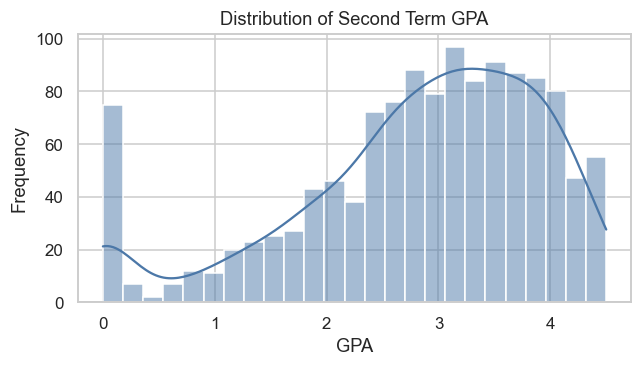

In [11]:
# explorer = DataExplorer(structured_data_file)
# explorer.run_full_analysis()

# Analyze target variable distribution
plt.figure(figsize=(6,3.5))

sns.histplot(y, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Second Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [12]:
# number of students have value 0 in second_term_gpa column
num_zero_gpa = (y == 0).sum()
print(f"Number of students with second term GPA of 0: {num_zero_gpa}")

Number of students with second term GPA of 0: 72


### Train-Test Protocol

In [13]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (893, 12), X_val: (128, 12), X_test: (256, 12)


In [14]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade
78,3.521739,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7
353,2.25,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7
1354,3.4,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8
510,4.214286,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9
338,2.547619,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9


### Data Cleaning

In [15]:
# Data cleaning
cleaner = DataCleaner(numeric_imputer="bayesian")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

# Target standardization
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test = scaler.transform(y_test.values.reshape(-1, 1)).flatten()


In [16]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner, project_path / "second_term_gpa_regression" / "models" / "best_second_term_regression_model" / "preprocessing_pipeline.pkl")
joblib.dump(scaler, project_path / "second_term_gpa_regression" / "models" / "best_second_term_regression_model" / "target_scaler.pkl")

# check the training after cleaning
display(X_train.head())

,first_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,high_school_average_mark_missing,english_grade_missing,...,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3,gpa_category_0,gpa_category_1,gpa_category_2,gpa_category_3
78,0.485630,1,0,0,3.0,0.335862,0.248844,7.0,1,0,...,True,False,False,True,False,False,False,False,False,True
353,-0.762264,0,0,1,2.0,0.270222,0.122663,7.0,0,0,...,False,True,False,False,True,False,False,False,True,False
1354,0.366174,1,0,0,4.0,0.253814,0.187655,8.0,1,0,...,True,False,False,False,True,False,False,False,False,True
510,1.165193,0,1,1,4.0,-0.751768,1.665857,9.0,0,0,...,False,True,False,False,True,False,False,False,False,True
338,-0.470226,0,1,1,2.0,-0.240773,-0.703704,9.0,0,0,...,False,True,False,True,False,False,False,False,True,False


### Experiment 1: Baseline Model - ANN

In [17]:
baseline_layers = [
    {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 32, 'activation': 'relu', 'batch_norm': False, 'dropout': 0.0},
]

baseline_model = build_dense_model(X_train.shape[1], baseline_layers)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,001 (62.50 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [18]:
baseline_model = compile_regression_model(baseline_model, optimizer_name='adam', learning_rate=0.001)

baseline_es, baseline_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'regression_model.keras',
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[baseline_es, baseline_mc],
    verbose=1,
)

Epoch 1/200
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1806 - mae: 0.7662 - r2: -15.5321 - rmse: 1.0789
Epoch 1: val_loss improved from None to 0.20548, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.8854 - mae: 0.6738 - r2: -12.4415 - rmse: 0.9410 - val_loss: 0.2055 - val_mae: 0.3699 - val_r2: -2.5208 - val_rmse: 0.4533
Epoch 2/200
21/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4602 - mae: 0.5234 - r2: -6.7831 - rmse: 0.6776
Epoch 2: val_loss did not improve from 0.20548
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3842 - mae: 0.4714 - r2: -4.8333 - rmse: 0.6199 - val_loss: 0.3240 - val_mae: 0.5144 - val_r2: -4.5513 - val_rmse: 0.56

### Baseline Evaluation

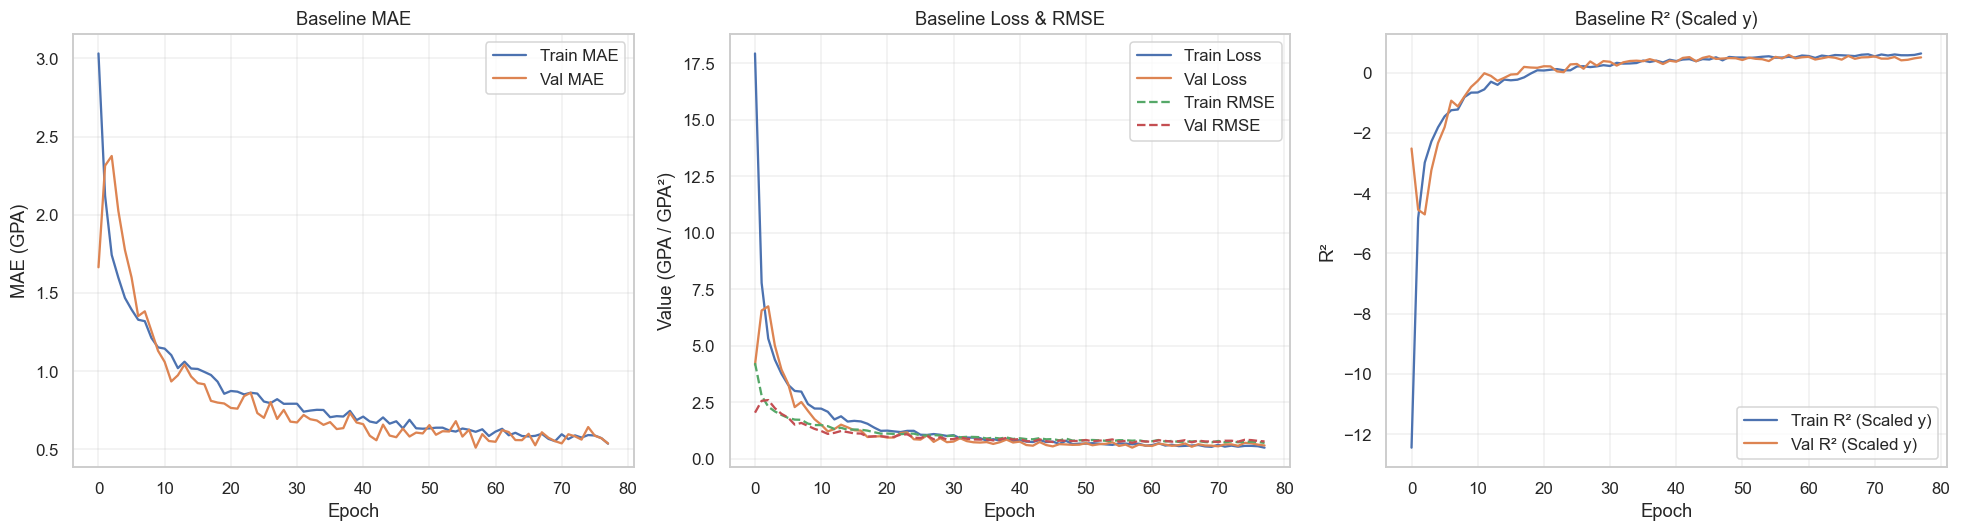


Best Epoch: 58
----------------------------------------
MAE (GPA)   -> Train: 0.6121 | Val: 0.5106
RMSE (GPA)  -> Train: 0.7997 | Val: 0.7017
Loss (GPA²) -> Train: 0.6396 | Val: 0.4924
R² (Scaled y) -> Train: 0.5205 | Val: 0.5834


In [19]:
plot_regression_history(history_baseline, title_prefix='Baseline')

In [20]:
baseline_val_metrics, baseline_val_df = evaluate_model_original_scale(
    baseline_model, X_val, y_val, scaler, split_name='Baseline Validation'
)
baseline_test_metrics, baseline_test_df = evaluate_model_original_scale(
    baseline_model, X_test, y_test, scaler, split_name='Baseline Test'
)

baseline_summary_df = pd.DataFrame([baseline_val_metrics, baseline_test_metrics]).set_index('split')
display(format_metrics_display(baseline_summary_df))
display(baseline_test_df.head(15))

Baseline Validation RMSE: 0.7017
Baseline Validation MSE:  0.4924
Baseline Validation MAE:              0.5106
Baseline Validation R² (Original GPA): 0.5834
Baseline Validation R² (Scaled y):     0.5834
Baseline Test RMSE: 0.6499
Baseline Test MSE:  0.4223
Baseline Test MAE:              0.5091
Baseline Test R² (Original GPA): 0.6172
Baseline Test R² (Scaled y):     0.6172


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline Validation,0.701696,0.492378,0.510639,0.583366,0.583366
Baseline Test,0.649874,0.422337,0.509075,0.617184,0.617184


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.222222,1.075182,2.147040,2.147040,4.609781
1,0.000000,1.949816,-1.949816,1.949816,3.801784
2,3.000000,1.135267,1.864733,1.864733,3.477228
3,1.857143,0.014551,1.842592,1.842592,3.395145
4,2.815789,4.342777,-1.526988,1.526988,2.331693
5,4.020833,2.527496,1.493337,1.493337,2.230054
6,3.095238,1.612870,1.482368,1.482368,2.197415
7,2.978261,1.501069,1.477192,1.477192,2.182095
8,0.250000,1.653415,-1.403415,1.403415,1.969573
9,0.000000,1.388700,-1.388700,1.388700,1.928487


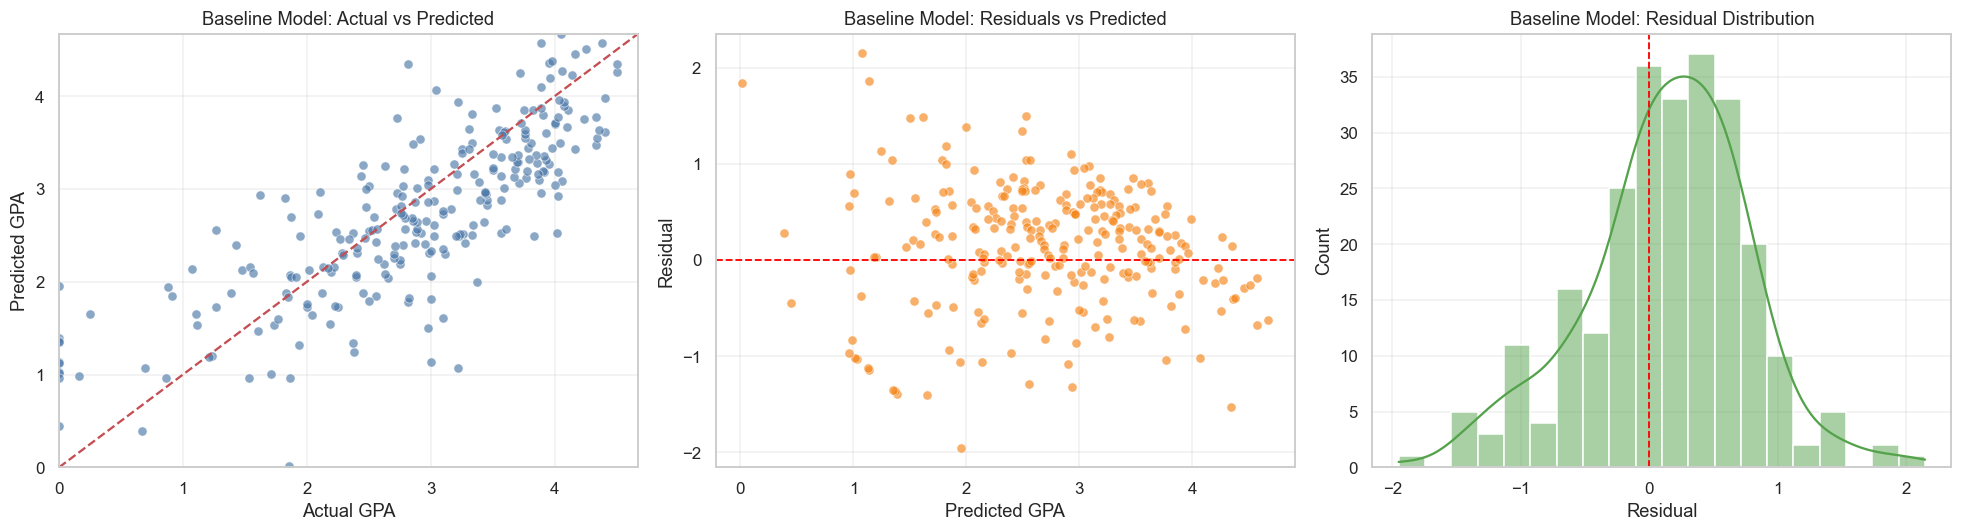

In [21]:
plot_prediction_diagnostics(baseline_test_df, title_prefix='Baseline Model')

### Experiment 2: Baseline Model - RNN with Bayesian Imputation

In [22]:
X_train_rnn = np.array(X_train).reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_rnn = np.array(X_val).reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_rnn = np.array(X_test).reshape(X_test.shape[0], X_test.shape[1], 1)

X_train_rnn = np.asarray(X_train_rnn).astype(np.float32)
X_val_rnn = np.asarray(X_val_rnn).astype(np.float32)
X_test_rnn = np.asarray(X_test_rnn).astype(np.float32)

y_train_rnn = np.asarray(y_train).astype(np.float32)
y_val_rnn = np.asarray(y_val).astype(np.float32)
y_test_rnn = np.asarray(y_test).astype(np.float32)

print(X_train_rnn.shape)   #

(893, 37, 1)


In [23]:
#build rnn model for based model above
from tensorflow.keras.layers import SimpleRNN, Input

baseline_rnn = Sequential([
    Input(shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    SimpleRNN(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    SimpleRNN(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    SimpleRNN(32, activation='tanh'),
    Dense(1)
])

baseline_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 37, 128)             │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 37, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 37, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 37, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 37, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 37, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,897 (128.50 KB)

 Trainable params: 32,513 (127.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [24]:
baseline_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
)

es_rnn, mc_rnn = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'rnn_ baseline_model.keras'
)   

In [25]:
history_rnn = baseline_rnn.fit(
    X_train_rnn, y_train_rnn,
    validation_data=(X_val_rnn, y_val_rnn),
    epochs=100,
    batch_size=32,
    callbacks = [es_rnn, mc_rnn],
    verbose=1
)

Epoch 1/100
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5496 - mae: 0.5819 - r2: -6.8398 - rmse: 0.7328
Epoch 1: val_loss improved from None to 0.06071, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\rnn_ baseline_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\rnn_ baseline_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.3635 - mae: 0.4679 - r2: -4.5187 - rmse: 0.6029 - val_loss: 0.0607 - val_mae: 0.1731 - val_r2: -0.0403 - val_rmse: 0.2464
Epoch 2/100
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1960 - mae: 0.3620 - r2: -2.2572 - rmse: 0.4425
Epoch 2: val_loss improved from 0.06071 to 0.03582, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\rnn_ baseline_model

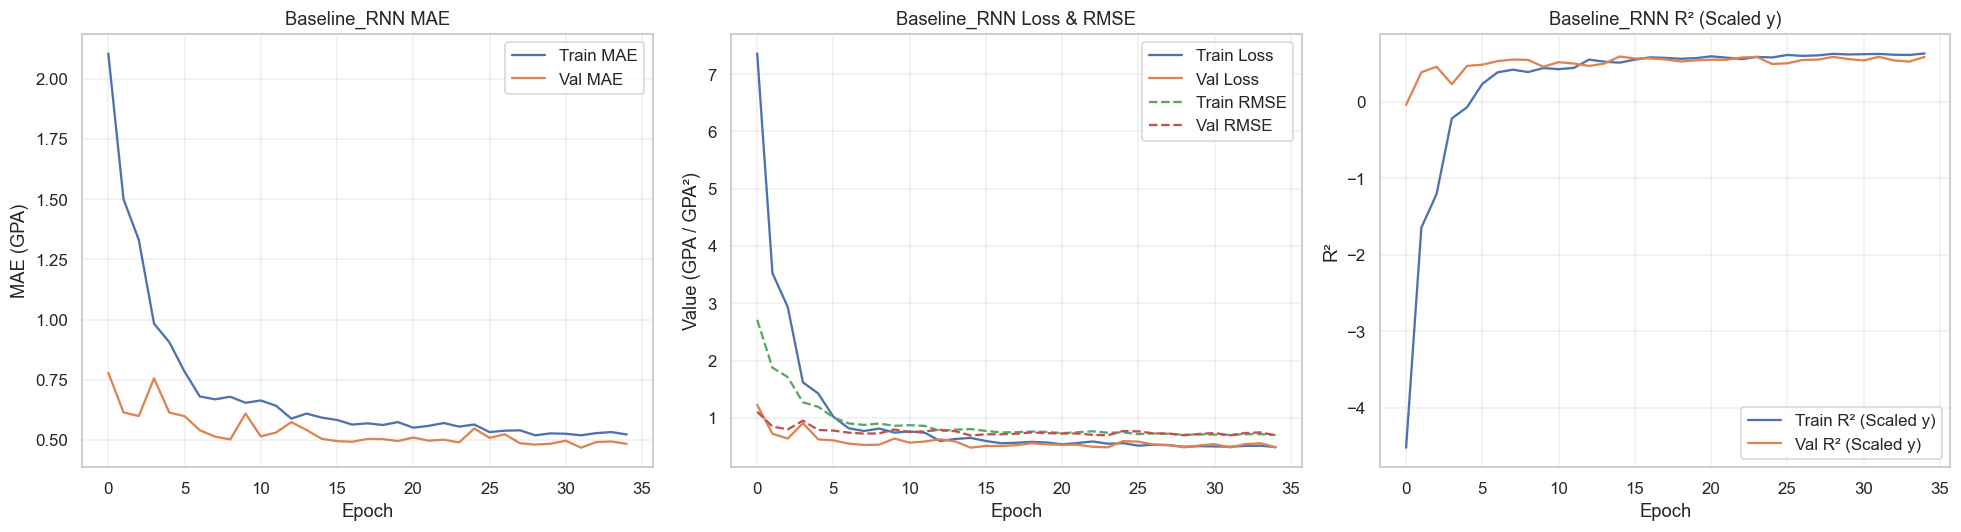


Best Epoch: 15
----------------------------------------
MAE (GPA)   -> Train: 0.5924 | Val: 0.5042
RMSE (GPA)  -> Train: 0.8072 | Val: 0.6943
Loss (GPA²) -> Train: 0.6516 | Val: 0.4821
R² (Scaled y) -> Train: 0.5115 | Val: 0.5921


In [26]:
plot_regression_history(history_rnn, title_prefix='Baseline_RNN')

In [27]:
baseline_rnn_val_metrics, baseline_rnn_val_df = evaluate_model_original_scale(
    baseline_rnn, X_val_rnn, y_val_rnn, scaler, split_name='Baseline RNN Validation'
)
baseline_rnn_test_metrics, baseline_rnn_test_df = evaluate_model_original_scale(
    baseline_rnn, X_test_rnn, y_test_rnn, scaler, split_name='Baseline RNN Test'
)

baseline_rnn_summary_df = pd.DataFrame([baseline_rnn_val_metrics, baseline_rnn_test_metrics]).set_index('split')
display(format_metrics_display(baseline_rnn_summary_df))
display(baseline_rnn_test_df.head(15))

Baseline RNN Validation RMSE: 0.6943
Baseline RNN Validation MSE:  0.4821
Baseline RNN Validation MAE:              0.5042
Baseline RNN Validation R² (Original GPA): 0.5921
Baseline RNN Validation R² (Scaled y):     0.5921
Baseline RNN Test RMSE: 0.6559
Baseline RNN Test MSE:  0.4302
Baseline RNN Test MAE:              0.5037
Baseline RNN Test R² (Original GPA): 0.6101
Baseline RNN Test R² (Scaled y):     0.6101


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline RNN Validation,0.694343,0.482112,0.504193,0.592053,0.592053
Baseline RNN Test,0.655885,0.430185,0.503668,0.610070,0.610070


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,2.234724,-2.234724,2.234724,4.993989
1,0.000000,2.159130,-2.159130,2.159130,4.661842
2,0.000000,2.105478,-2.105478,2.105478,4.433037
3,0.250000,2.142553,-1.892553,1.892553,3.581756
4,0.000000,1.865645,-1.865645,1.865645,3.480630
5,0.000000,1.861507,-1.861507,1.861507,3.465207
6,0.000000,1.665478,-1.665478,1.665478,2.773816
7,3.000000,1.429047,1.570953,1.570953,2.467895
8,0.157895,1.672682,-1.514787,1.514787,2.294579
9,1.269231,2.740414,-1.471183,1.471183,2.164381


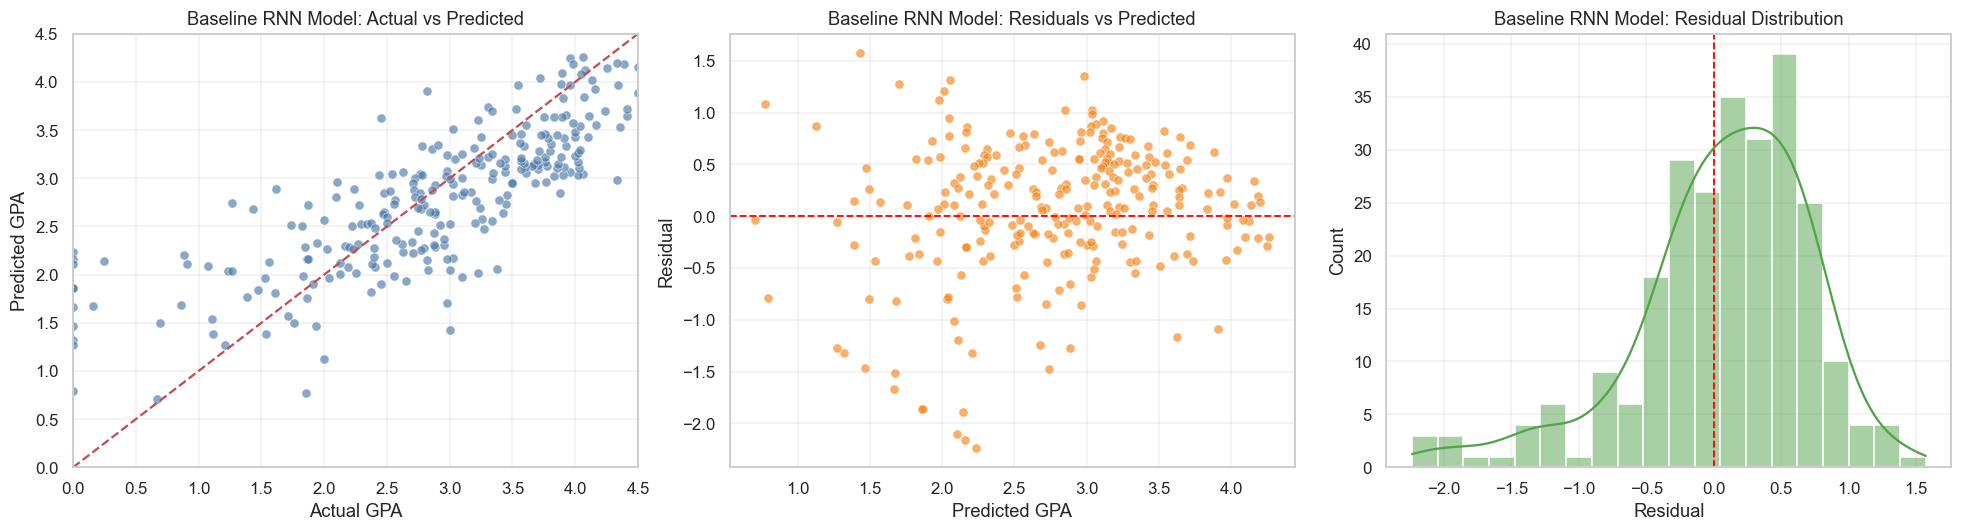

In [28]:
_, baseline_rnn_diag_df = evaluate_and_plot_diagnostics(
    baseline_rnn,
    X_test_rnn,
    y_test_rnn,
    scaler,
    split_name='Baseline RNN Test',
    title_prefix='Baseline RNN Model',
    print_summary=False,
)

### Experiment 3: Baseline Model - LSTM with Bayesian Imputation

In [29]:
from tensorflow.keras.layers import  LSTM

# make sure dtype is numeric
X_train_lstm = np.asarray(X_train, dtype=np.float32).reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_lstm   = np.asarray(X_val, dtype=np.float32).reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_lstm  = np.asarray(X_test, dtype=np.float32).reshape(X_test.shape[0], X_test.shape[1], 1)

y_train_lstm = np.asarray(y_train, dtype=np.float32)
y_val_lstm   = np.asarray(y_val, dtype=np.float32)
y_test_lstm  = np.asarray(y_test, dtype=np.float32)


In [30]:
baseline_lstm = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),

    LSTM(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(32, activation='tanh'),
    Dense(1)
])

baseline_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 37, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 37, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 37, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 37, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 37, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 37, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 129,185 (504.63 KB)

 Trainable params: 128,801 (503.13 KB)

 Non-trainable params: 384 (1.50 KB)

In [31]:
baseline_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
)

es_lstm, mc_lstm = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'lstm_baseline_model.keras'
)

history_lstm = baseline_lstm.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=100,
    batch_size=32,
    callbacks=[es_lstm, mc_lstm],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.1176 - mae: 0.2547 - r2: -0.6279 - rmse: 0.3318
Epoch 1: val_loss improved from None to 0.48666, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\lstm_baseline_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\lstm_baseline_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - loss: 0.0638 - mae: 0.1859 - r2: 0.0311 - rmse: 0.2526 - val_loss: 0.4867 - val_mae: 0.6509 - val_r2: -7.3388 - val_rmse: 0.6976
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0339 - mae: 0.1395 - r2: 0.5008 - rmse: 0.1838
Epoch 2: val_loss did not improve from 0.48666
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0319 - mae: 0.1344 - r2: 0.5163 - rmse: 0.1785 - val_loss: 0.5006 - val_mae: 0.6621 - val_r2: -7.5774 - val_rmse:

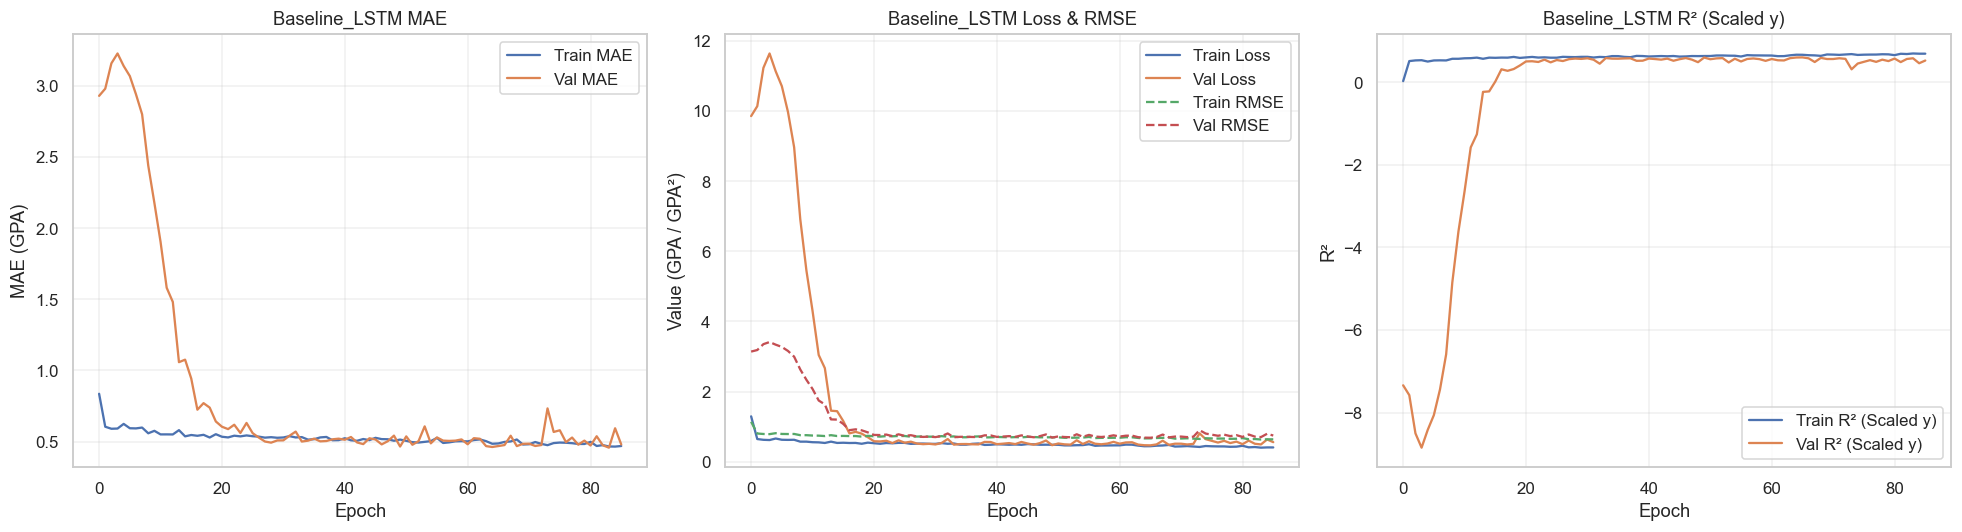


Best Epoch: 66
----------------------------------------
MAE (GPA)   -> Train: 0.4875 | Val: 0.4693
RMSE (GPA)  -> Train: 0.6646 | Val: 0.6826
Loss (GPA²) -> Train: 0.4417 | Val: 0.4660
R² (Scaled y) -> Train: 0.6689 | Val: 0.6057


In [32]:
plot_regression_history(history_lstm, title_prefix='Baseline_LSTM')

In [33]:
baseline_lstm_val_metrics, baseline_lstm_val_df = evaluate_model_original_scale(
    baseline_lstm, X_val_lstm, y_val_lstm, scaler, split_name='Baseline LSTM Validation'
)
baseline_lstm_test_metrics, baseline_lstm_test_df = evaluate_model_original_scale(
    baseline_lstm, X_test_lstm, y_test_lstm, scaler, split_name='Baseline LSTM Test'
)

baseline_lstm_summary_df = pd.DataFrame([baseline_lstm_val_metrics, baseline_lstm_test_metrics]).set_index('split')
display(format_metrics_display(baseline_lstm_summary_df))
display(baseline_lstm_test_df.head(15))

Baseline LSTM Validation RMSE: 0.6826
Baseline LSTM Validation MSE:  0.4660
Baseline LSTM Validation MAE:              0.4693
Baseline LSTM Validation R² (Original GPA): 0.6057
Baseline LSTM Validation R² (Scaled y):     0.6057
Baseline LSTM Test RMSE: 0.5743
Baseline LSTM Test MSE:  0.3298
Baseline LSTM Test MAE:              0.4523
Baseline LSTM Test R² (Original GPA): 0.7010
Baseline LSTM Test R² (Scaled y):     0.7010


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline LSTM Validation,0.682626,0.465978,0.469260,0.605705,0.605705
Baseline LSTM Test,0.574305,0.329826,0.452328,0.701038,0.701038


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.000000,1.233595,1.766405,1.766405,3.120187
1,0.250000,1.949986,-1.699986,1.699986,2.889951
2,0.000000,1.646146,-1.646146,1.646146,2.709798
3,0.000000,1.543804,-1.543804,1.543804,2.383332
4,1.269231,2.763333,-1.494102,1.494102,2.232342
5,1.619048,3.077090,-1.458042,1.458042,2.125886
6,0.000000,1.429836,-1.429836,1.429836,2.044430
7,0.000000,1.359985,-1.359985,1.359985,1.849559
8,4.333333,3.031153,1.302180,1.302180,1.695672
9,2.978261,1.692809,1.285452,1.285452,1.652388


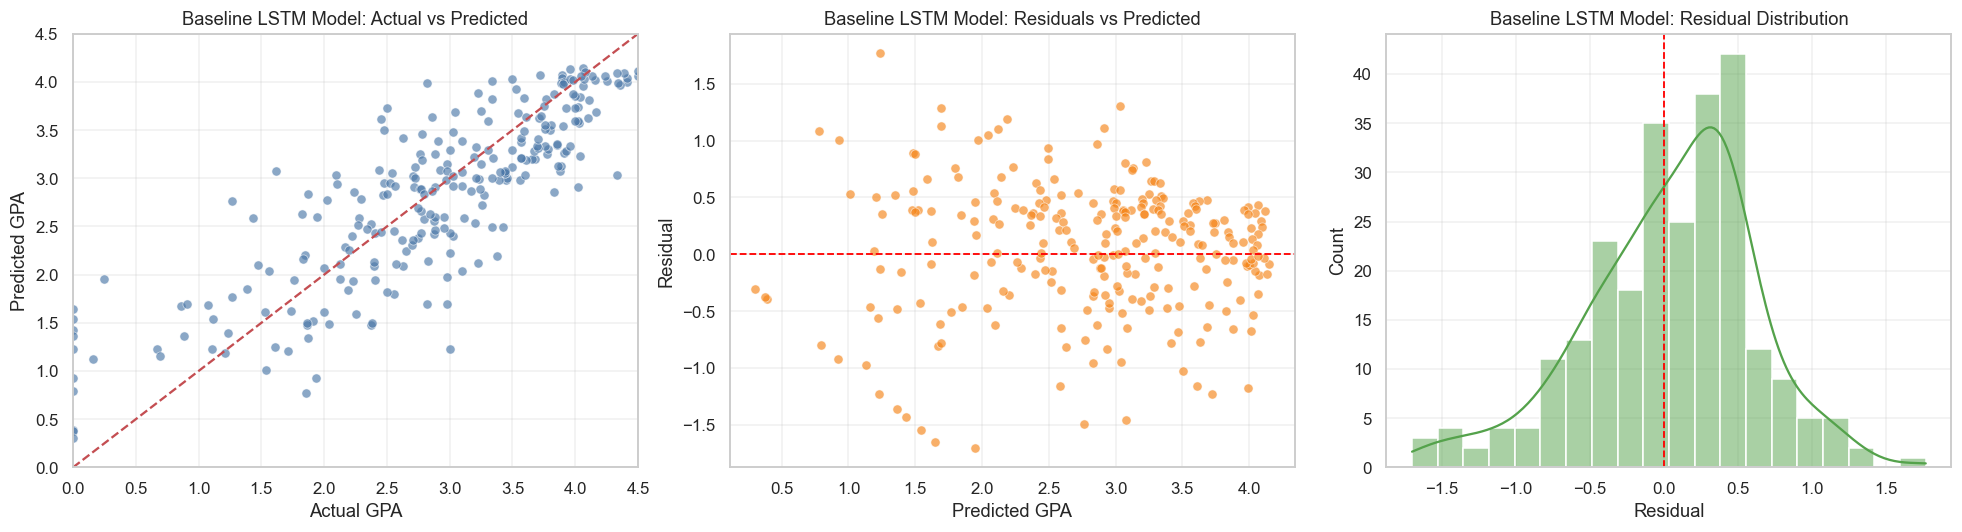

In [34]:
_, baseline_lstm_diag_df = evaluate_and_plot_diagnostics(
    baseline_lstm,
    X_test_lstm,
    y_test_lstm,
    scaler,
    split_name='Baseline LSTM Test',
    title_prefix='Baseline LSTM Model',
    print_summary=False,
)

### Experiment 4: Keras Tuner - Automatic Hyperband Search for LSTM Based on Baseline Results

In [35]:
def build_tuner_model(hp):
    num_layers = hp.Int('num_layers', 1, 5)
    layer_specs = [{'units': hp.Choice(f'neurons_{i}', [64, 128, 256, 512, 1024]),
                    'activation': hp.Choice(f'act_{i}', ['relu', 'tanh', 'elu']),
                    'dropout': hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)} for i in range(num_layers)]

    tuner_model = Sequential([Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
                              LSTM(layer_specs[0]['units'], activation=layer_specs[0]['activation'], return_sequences=(num_layers > 1)),
                              BatchNormalization(),
                              Dropout(layer_specs[0]['dropout'])])

    for i in range(1, num_layers):
        tuner_model.add(LSTM(layer_specs[i]['units'], activation=layer_specs[i]['activation'], return_sequences=(i < num_layers - 1)))
        tuner_model.add(BatchNormalization())
        tuner_model.add(Dropout(layer_specs[i]['dropout']))

    tuner_model.add(Dense(1))
    return compile_regression_model(
        tuner_model,
        optimizer_name=hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop']),
        learning_rate=hp.Choice('learning_rate', [0.0001, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.01])
    )


def show_best_hyperparameters(hyperparameters):
    rows = [{'hyperparameter': k, 'value': v} for k, v in hyperparameters.values.items()]
    display(pd.DataFrame(rows))

In [ ]:
tuner_dir = project_path / 'second_term_gpa_regression' / 'tuner' / 'student_tuner'
if tuner_dir.exists():
    shutil.rmtree(tuner_dir, ignore_errors=True)

print_header('KERAS TUNER SEARCH')

hyperband_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective='val_loss',
    max_epochs=40,
    factor=3,
    directory=tuner_dir,
    project_name='student_tuner',
    seed=42,
    overwrite=True,
)

search_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0,
    mode='min',
)

search_start = time.time()
hyperband_tuner.search(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=60,
    callbacks=[search_stop],
    verbose=1,
)
search_time = time.time() - search_start

print(f'Search completed in {search_time / 60:.1f} minutes')
hyperband_tuner.results_summary(num_trials=10)

best_hps = hyperband_tuner.get_best_hyperparameters(1)[0]
print_header('BEST HYPERPARAMETERS')
show_best_hyperparameters(best_hps)

Trial 67 Complete [00h 01m 50s]
val_loss: 0.031824979931116104

Best val_loss So Far: 0.02949560061097145
Total elapsed time: 02h 20m 01s

Search: Running Trial #68

Value             |Best Value So Far |Hyperparameter
5                 |1                 |num_layers
1024              |1024              |neurons_0
relu              |relu              |act_0
0.3               |0.5               |dropout_0
rmsprop           |sgd               |optimizer
0.001             |0.0005            |learning_rate
64                |512               |neurons_1
elu               |elu               |act_1
0.2               |0.4               |dropout_1
1024              |256               |neurons_2
tanh              |tanh              |act_2
0.2               |0.3               |dropout_2
512               |256               |neurons_3
relu              |tanh              |act_3
0.3               |0.5               |dropout_3
512               |256               |neurons_4
tanh              |relu 

### Hyperband Results

In [ ]:
all_trials = list(hyperband_tuner.oracle.trials.values())

target_scale = get_target_scale(scaler)
mse_scale = target_scale ** 2

rows = []
for t in all_trials:
    hp = t.hyperparameters.values

    num_layers = hp.get('num_layers', 0)
    layer_parts = []

    for i in range(num_layers):
        neurons = hp.get(f'neurons_{i}')
        act = hp.get(f'act_{i}')
        drop = hp.get(f'dropout_{i}')
        layer_parts.append(f"{neurons}-{act}-Drop{drop}")

    architecture = f"{num_layers}L-" + "-".join(layer_parts)
    experiment = f"{architecture}-{hp.get('optimizer')}-LR{hp.get('learning_rate')}"

    rows.append({
        'Experiment': experiment,
        'Loss (GPA²)': (t.metrics.metrics['loss'].get_best_value() * mse_scale) if 'loss' in t.metrics.metrics else None,
        'Val_Loss (GPA²)': (t.metrics.metrics['val_loss'].get_best_value() * mse_scale) if 'val_loss' in t.metrics.metrics else None,
        'MAE (GPA)': (t.metrics.metrics['mae'].get_best_value() * target_scale) if 'mae' in t.metrics.metrics else None,
        'Val_MAE (GPA)': (t.metrics.metrics['val_mae'].get_best_value() * target_scale) if 'val_mae' in t.metrics.metrics else None,
        'RMSE (GPA)': (t.metrics.metrics['rmse'].get_best_value() * target_scale) if 'rmse' in t.metrics.metrics else None,
        'Val_RMSE (GPA)': (t.metrics.metrics['val_rmse'].get_best_value() * target_scale) if 'val_rmse' in t.metrics.metrics else None,
        'R2': t.metrics.metrics['r2'].get_best_value() if 'r2' in t.metrics.metrics else None,
        'Val_R2': t.metrics.metrics['val_r2'].get_best_value() if 'val_r2' in t.metrics.metrics else None,
        'Epochs': hp.get('tuner/epochs'),
        'Trial_ID': t.trial_id
    })

tuning_results_df = pd.DataFrame(rows).sort_values('Val_Loss (GPA²)').reset_index(drop=True)
tuning_results_df.insert(0, '#', range(1, len(tuning_results_df) + 1))

tuning_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'keras_tuner_results_comb_regression_bayesian.csv',
    index=False,
)

display_df = tuning_results_df.head(20).copy()

for col in ['Loss (GPA²)', 'Val_Loss (GPA²)', 'MAE (GPA)', 'Val_MAE (GPA)', 'RMSE (GPA)', 'Val_RMSE (GPA)', 'R2', 'Val_R2']:
    display_df[col] = display_df[col].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "")

print("=" * 160)
print("TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)")
print("=" * 160)
print(display_df.to_string(index=False))

TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)
 #                                                                                          Experiment Loss (GPA²) Val_Loss (GPA²) MAE (GPA) Val_MAE (GPA) RMSE (GPA) Val_RMSE (GPA)      R2 Val_R2  Epochs Trial_ID
 1                                                                      1L-128-elu-Drop0.2-adam-LR0.01      0.5448          0.4871    0.5672        0.5179     0.7381         0.6979  0.5915 0.5878      40     0066
 2                                                     1L-256-tanh-Drop0.30000000000000004-adam-LR0.01      0.5389          0.5277    0.5556        0.5135     0.7341         0.7264  0.5960 0.5535      40     0070
 3                                                   2L-512-tanh-Drop0.5-128-tanh-Drop0.2-adam-LR0.003      0.7184          0.5987    0.6528        0.5958     0.8476         0.7737  0.4614 0.4934      40     0068
 4                                                    2L-256-elu-Drop0.2-12

In [36]:
from keras_tuner import Hyperband

reload_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective='val_loss',
    max_epochs=40,
    factor=3,
    directory=project_path / 'second_term_gpa_regression' / 'tuner' / 'student_tuner',
    project_name='student_tuner',
    seed=42,
    overwrite=False,
)

reload_tuner.reload()

# best_model = hyperband_tuner.hypermodel.build(best_hps)
best_model = reload_tuner.get_best_models(num_models=1)[0]
best_model.summary()

best_es, best_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_regression_model_bayesian.keras',
)

history_best = best_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=200,
    callbacks=[best_es, best_mc],
    verbose=1,
)

print('Training completed.')

Reloading Tuner from C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\tuner\student_tuner\student_tuner\tuner0.json



C:\Vivek\Soft\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 37, 512)             │       1,052,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 37, 512)             │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 37, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 128)                 │         328,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,383,553 (5.28 MB)

 Trainable params: 1,382,273 (5.27 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - loss: 0.1641 - mae: 0.2836 - r2: -1.7365 - rmse: 0.4004
Epoch 1: val_loss improved from None to 0.20805, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 256ms/step - loss: 0.1525 - mae: 0.2857 - r2: -1.3157 - rmse: 0.3906 - val_loss: 0.2080 - val_mae: 0.4115 - val_r2: -2.5649 - val_rmse: 0.4561
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 0.0941 - mae: 0.2432 - r2: -0.4018 - rmse: 0.3064
Epoch 2: val_loss improved from 0.20805 to 0.14930, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\

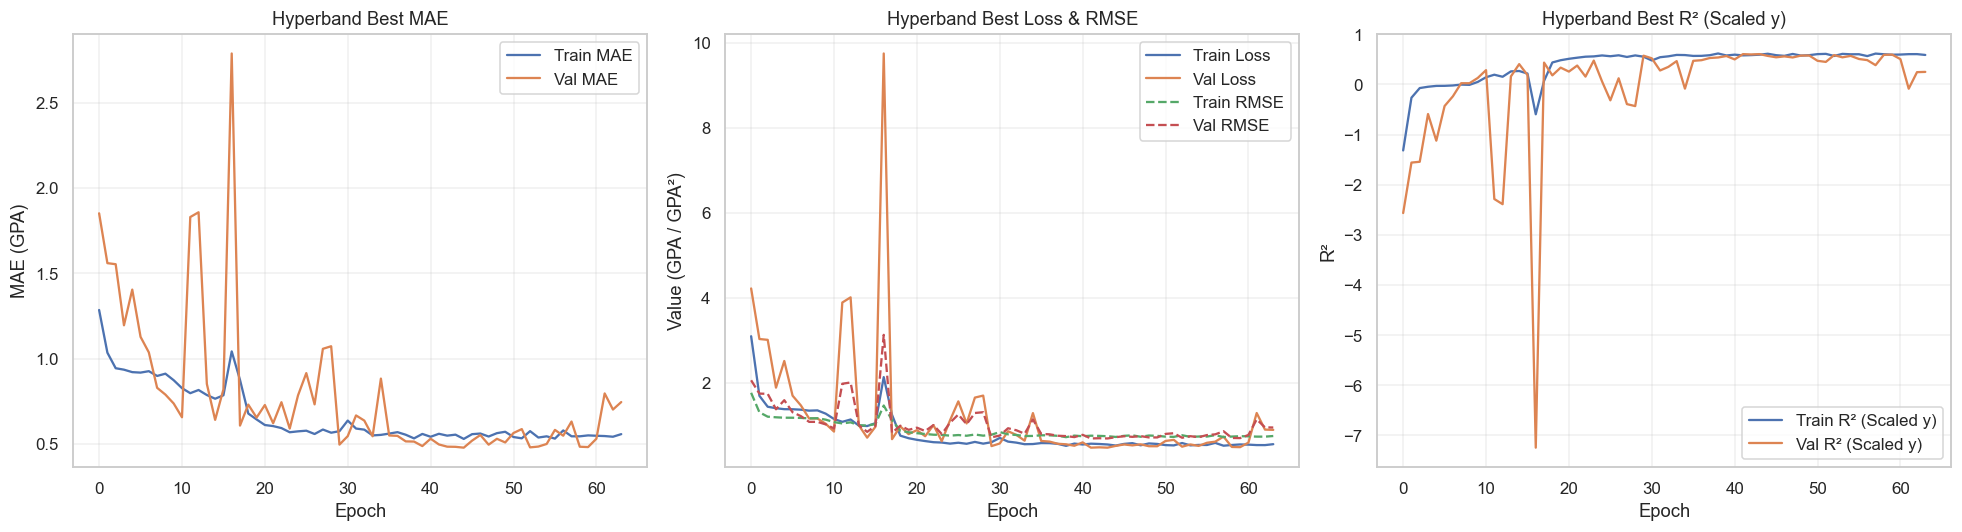


Best Epoch: 44
----------------------------------------
MAE (GPA)   -> Train: 0.5550 | Val: 0.4837
RMSE (GPA)  -> Train: 0.7359 | Val: 0.6830
Loss (GPA²) -> Train: 0.5415 | Val: 0.4665
R² (Scaled y) -> Train: 0.5940 | Val: 0.6053


In [37]:
plot_regression_history(history_best, title_prefix='Hyperband Best')

In [38]:
best_val_metrics, best_val_df = evaluate_model_original_scale(
    best_model, X_val_lstm, y_val_lstm, scaler, split_name='Hyperband Validation'
)
best_test_metrics, best_test_df = evaluate_model_original_scale(
    best_model, X_test_lstm, y_test_lstm, scaler, split_name='Hyperband Test'
)

best_summary_df = pd.DataFrame([best_val_metrics, best_test_metrics]).set_index('split')
display(format_metrics_display(best_summary_df))
display(best_test_df.head(15))

Hyperband Validation RMSE: 0.6830
Hyperband Validation MSE:  0.4665
Hyperband Validation MAE:              0.4837
Hyperband Validation R² (Original GPA): 0.6053
Hyperband Validation R² (Scaled y):     0.6053
Hyperband Test RMSE: 0.5948
Hyperband Test MSE:  0.3538
Hyperband Test MAE:              0.4474
Hyperband Test R² (Original GPA): 0.6793
Hyperband Test R² (Scaled y):     0.6793


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Hyperband Validation,0.683014,0.466508,0.483719,0.605256,0.605256
Hyperband Test,0.594830,0.353823,0.447436,0.679286,0.679286


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,2.048172,-2.048172,2.048172,4.195007
1,0.250000,2.270866,-2.020866,2.020866,4.083898
2,0.000000,1.823335,-1.823335,1.823335,3.324551
3,3.000000,1.265017,1.734983,1.734983,3.010166
4,0.909091,2.458254,-1.549163,1.549163,2.399907
5,1.269231,2.807041,-1.537810,1.537810,2.364860
6,0.000000,1.490748,-1.490748,1.490748,2.222330
7,1.431818,2.887690,-1.455872,1.455872,2.119563
8,0.000000,1.436890,-1.436890,1.436890,2.064651
9,2.978261,1.561379,1.416882,1.416882,2.007554


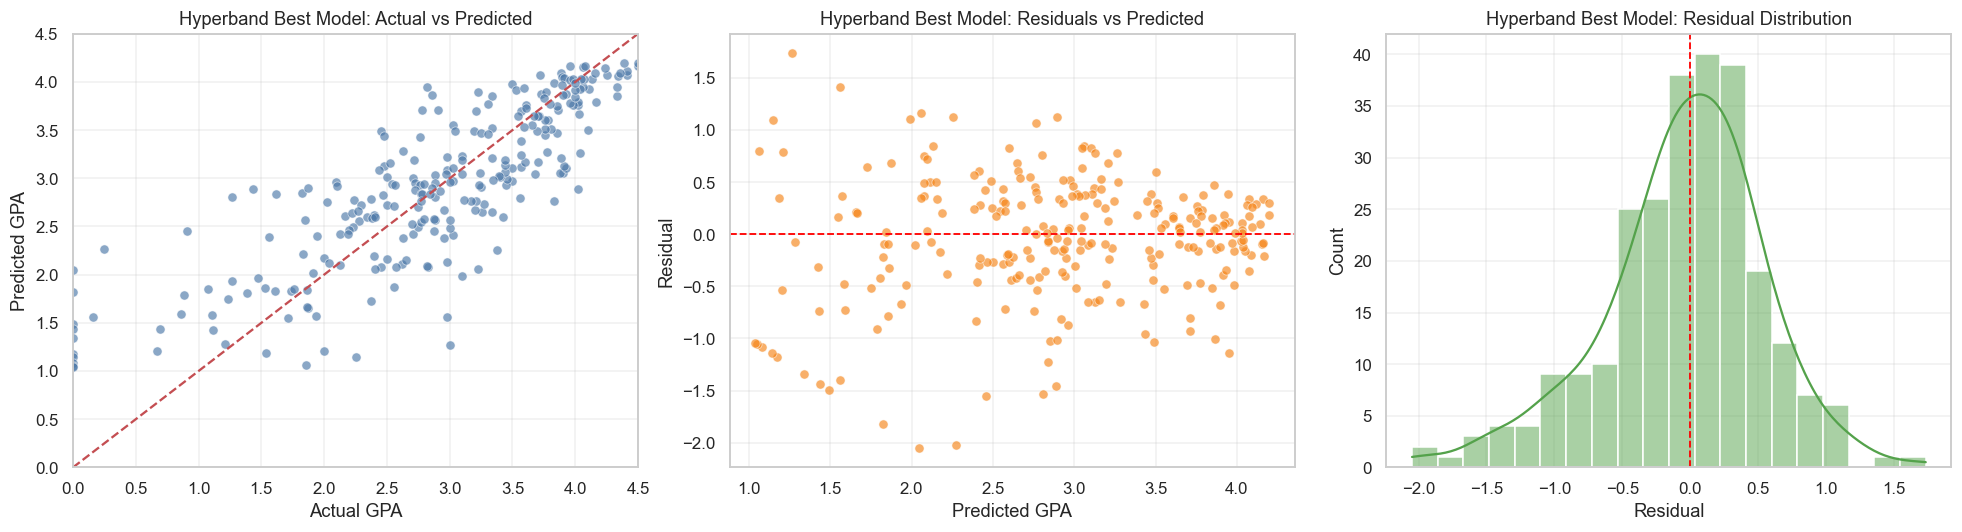

In [39]:
plot_prediction_diagnostics(best_test_df, title_prefix='Hyperband Best Model')

### Experiment 5: Custom Model based on Hyperband Findings

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization

custom_layers = [
    {'units': 512, 'dropout': 0.1},
    {'units': 128, 'dropout': 0.2},
]

custom_model = Sequential([
      Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
])

# Add LSTM layers
for i, spec in enumerate(custom_layers):
    return_seq = i < len(custom_layers) - 1  # True for all except last layer
    
    custom_model.add(LSTM(spec['units'], return_sequences=return_seq))
    
    custom_model.add(BatchNormalization())
    
    if spec.get('dropout', 0.0) > 0:
        custom_model.add(Dropout(spec['dropout']))

# Output layer (regression)
custom_model.add(Dense(1))

custom_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 37, 512)             │       1,052,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 37, 512)             │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 37, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 128)                 │         328,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,383,553 (5.28 MB)

 Trainable params: 1,382,273 (5.27 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [41]:
custom_model = compile_regression_model(custom_model, optimizer_name='sgd', learning_rate=0.0009)

custom_es, custom_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'custom_model_bayesian.keras',
)

history_custom = custom_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=200,
    callbacks=[custom_es, custom_mc],
    verbose=1,
)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 1.5542 - mae: 0.9694 - r2: -22.2825 - rmse: 1.2412
Epoch 1: val_loss improved from None to 0.09958, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 239ms/step - loss: 1.1490 - mae: 0.8123 - r2: -16.4428 - rmse: 1.0719 - val_loss: 0.0996 - val_mae: 0.2755 - val_r2: -0.7064 - val_rmse: 0.3156
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 0.3766 - mae: 0.4669 - r2: -4.5822 - rmse: 0.6128
Epoch 2: val_loss improved from 0.09958 to 0.06430, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_mo

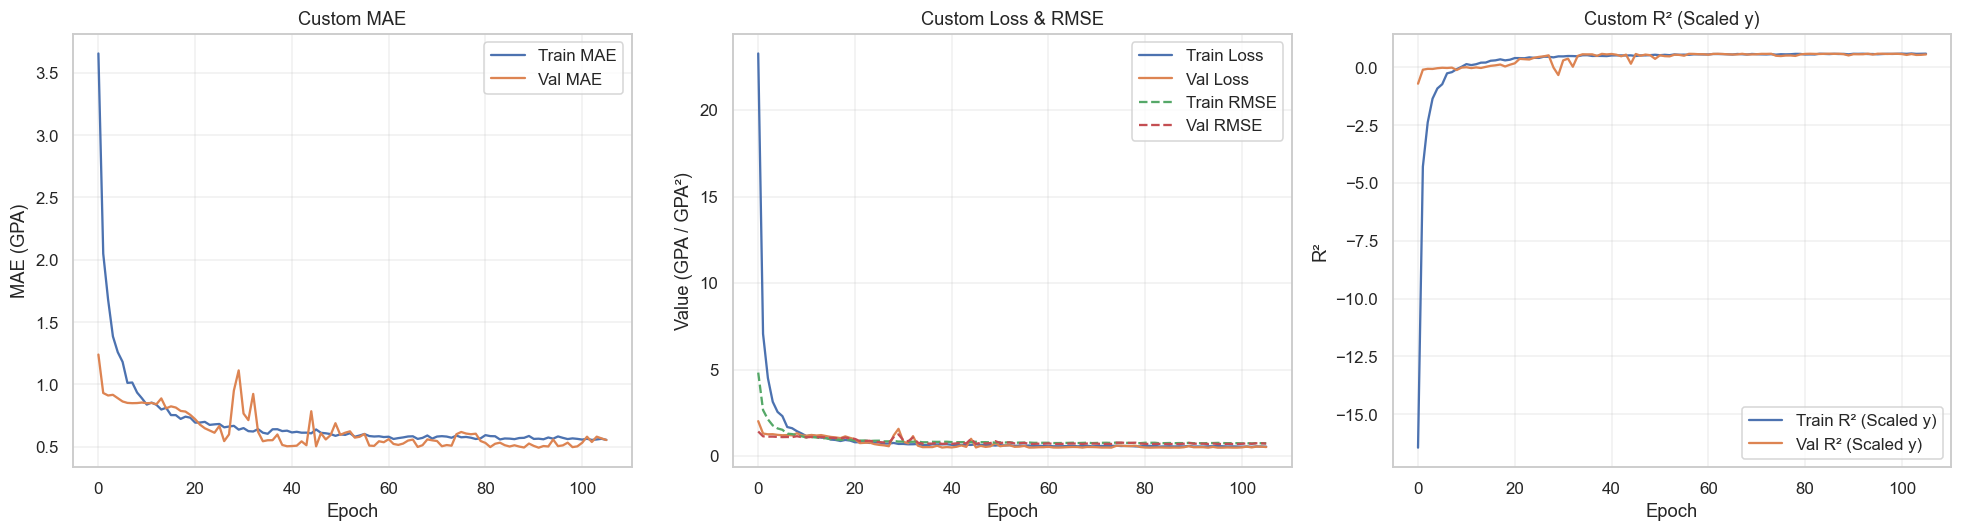


Best Epoch: 86
----------------------------------------
MAE (GPA)   -> Train: 0.5655 | Val: 0.5023
RMSE (GPA)  -> Train: 0.7543 | Val: 0.6966
Loss (GPA²) -> Train: 0.5689 | Val: 0.4853
R² (Scaled y) -> Train: 0.5735 | Val: 0.5894


In [42]:
plot_regression_history(history_custom, title_prefix='Custom')

In [43]:
custom_val_metrics, custom_val_df = evaluate_model_original_scale(
    custom_model, X_val_lstm, y_val_lstm, scaler, split_name='Custom Validation'
)
custom_test_metrics, custom_test_df = evaluate_model_original_scale(
    custom_model, X_test_lstm, y_test_lstm, scaler, split_name='Custom Test'
)

custom_summary_df = pd.DataFrame([custom_val_metrics, custom_test_metrics]).set_index('split')
display(format_metrics_display(custom_summary_df))
display(custom_test_df.head(15))

Custom Validation RMSE: 0.6966
Custom Validation MSE:  0.4853
Custom Validation MAE:              0.5023
Custom Validation R² (Original GPA): 0.5894
Custom Validation R² (Scaled y):     0.5894
Custom Test RMSE: 0.5949
Custom Test MSE:  0.3539
Custom Test MAE:              0.4652
Custom Test R² (Original GPA): 0.6792
Custom Test R² (Scaled y):     0.6792


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Custom Validation,0.696610,0.485265,0.502330,0.589384,0.589384
Custom Test,0.594918,0.353928,0.465163,0.679191,0.679191


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.250000,2.228176,-1.978176,1.978176,3.913181
1,0.000000,1.914840,-1.914840,1.914840,3.666611
2,1.619048,3.345450,-1.726402,1.726402,2.980465
3,3.000000,1.379137,1.620863,1.620863,2.627196
4,2.978261,1.465274,1.512987,1.512987,2.289130
5,0.000000,1.472686,-1.472686,1.472686,2.168805
6,0.000000,1.452942,-1.452942,1.452942,2.111040
7,0.000000,1.428060,-1.428060,1.428060,2.039356
8,4.333333,3.012268,1.321065,1.321065,1.745214
9,0.000000,1.316136,-1.316136,1.316136,1.732214


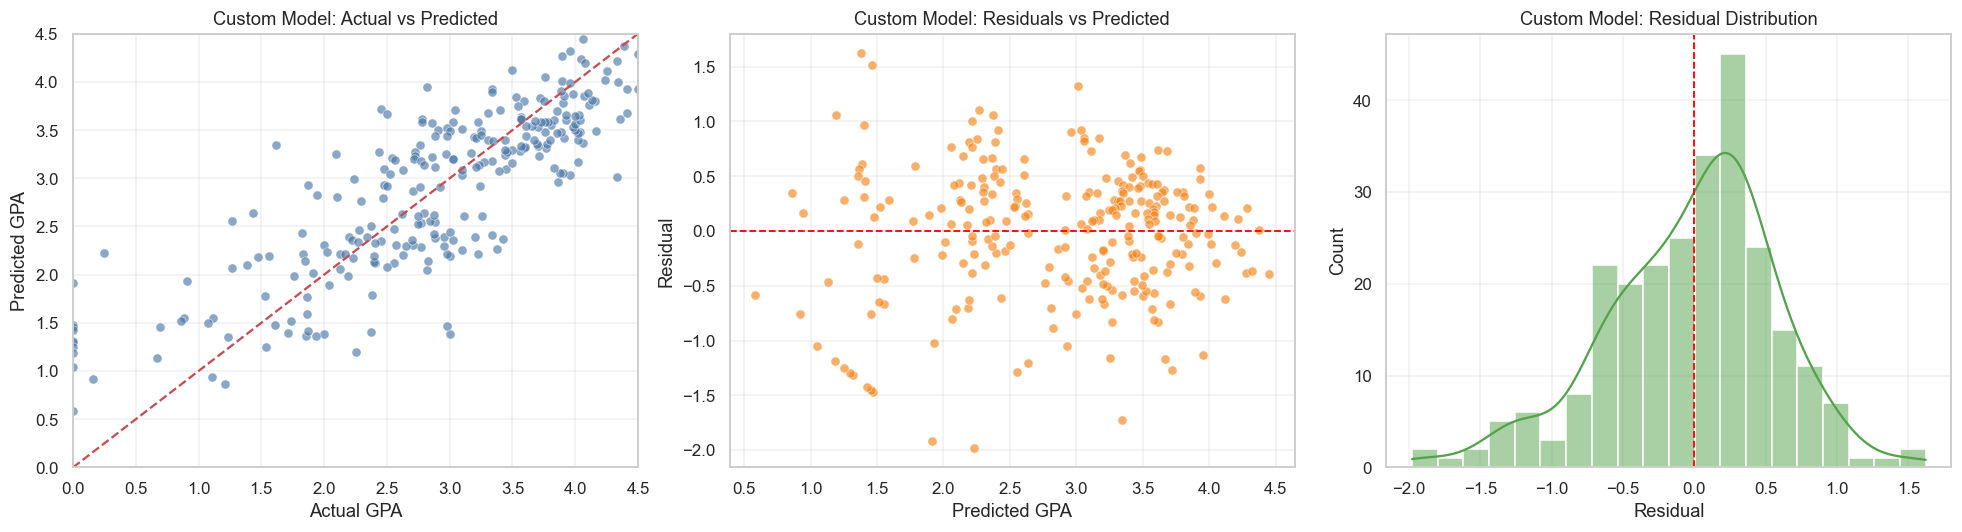

In [44]:
plot_prediction_diagnostics(custom_test_df, title_prefix='Custom Model')

### Experiment 5: Local Search around the Custom Architecture

In [45]:
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense, BatchNormalization

def build_lstm_model(input_shape, layer_specs):
    model = Sequential([
        Input(shape=input_shape)
    ])

    for i, spec in enumerate(layer_specs):
        return_seq = i < len(layer_specs) - 1
        model.add(LSTM(spec['units'], activation=spec.get('activation', 'tanh'), return_sequences=return_seq))
        if spec.get('batch_norm', False):
            model.add(BatchNormalization())
        if spec.get('dropout', 0) > 0:
            model.add(Dropout(spec['dropout']))

    model.add(Dense(1))
    return model

In [46]:
# trying to find the local minimum around the custom model configuration by varying learning rate and batch size

base_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.10},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.20},
]

local_search_configs = [

    {'trial_name': 'SGD-lr0.00090-bs32', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 32},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.001-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.001, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.005-bs128', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.005, 'batch_size': 128},
]

local_search_results = []
local_search_models = {}
local_search_histories = {}
best_local_model = None
best_local_history = None
best_local_metrics = None
best_local_config = None
best_local_sort_key = None

for trial_idx, config in enumerate(local_search_configs, start=1):
    print_header(config['trial_name'])

    trial_model = build_lstm_model(X_train_lstm.shape[1:], config['layers'])
    trial_model = compile_regression_model(
        trial_model,
        optimizer_name=config['optimizer'],
        learning_rate=config['learning_rate'],
        clipnorm=1.0,
    )

    trial_es = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        mode='min',
    )

    trial_history = trial_model.fit(
        X_train_lstm, y_train_lstm,
        validation_data=(X_val_lstm, y_val_lstm),
        epochs=200,
        batch_size=config['batch_size'],
        callbacks=[trial_es, TerminateOnNaN()],
        verbose=1,
    )

    non_finite_epoch, non_finite_metric = get_non_finite_history_event(trial_history)
    trial_status = 'completed'
    failure_reason = ''

    try:
        trial_val_metrics, _ = evaluate_model_original_scale(
            trial_model, X_val_lstm, y_val_lstm, scaler, split_name=f"{config['trial_name']} Validation", print_summary=False
        )
        trial_test_metrics, _ = evaluate_model_original_scale(
            trial_model, X_test_lstm, y_test_lstm, scaler, split_name=f"{config['trial_name']} Test", print_summary=False
        )
    except ValueError as exc:
        trial_status = 'failed'
        failure_reason = str(exc)
        if non_finite_epoch is not None:
            failure_reason += f" Training became non-finite at epoch {non_finite_epoch} ({non_finite_metric})."
        print(f"Skipping {config['trial_name']}: {failure_reason}")
        trial_val_metrics = empty_regression_metrics(f"{config['trial_name']} Validation")
        trial_test_metrics = empty_regression_metrics(f"{config['trial_name']} Test")

    best_epoch = get_best_epoch_from_history(trial_history)
    local_result = {
        'trial': trial_idx,
        'trial_name': config['trial_name'],
        'optimizer': config['optimizer'],
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'best_epoch': best_epoch,
        'status': trial_status,
        'failure_reason': failure_reason,
        'val_rmse': trial_val_metrics['rmse'],
        'val_mae': trial_val_metrics['mae'],
        'val_r2_original': trial_val_metrics['r2_original'],
        'val_r2_scaled': trial_val_metrics['r2_scaled'],
        'test_rmse': trial_test_metrics['rmse'],
        'test_mae': trial_test_metrics['mae'],
        'test_r2_original': trial_test_metrics['r2_original'],
        'test_r2_scaled': trial_test_metrics['r2_scaled'],
        'architecture': ' | '.join([f"{layer['units']}:{layer['activation']}" for layer in config['layers']]),
    }
    local_search_results.append(local_result)
    local_search_models[f"{trial_idx:02d}_{config['trial_name']}"] = trial_model
    local_search_histories[f"{trial_idx:02d}_{config['trial_name']}"] = trial_history

    if trial_status == 'completed':
        sort_key = (trial_val_metrics['r2_original'], -trial_val_metrics['rmse'])
        if best_local_sort_key is None or sort_key > best_local_sort_key:
            best_local_sort_key = sort_key
            best_local_model = trial_model
            best_local_history = trial_history
            best_local_metrics = local_result
            best_local_config = config

local_search_results_df = pd.DataFrame(local_search_results)
local_search_results_df['sort_status'] = (local_search_results_df['status'] != 'completed').astype(int)
local_search_results_df = local_search_results_df.sort_values(
    ['sort_status', 'val_r2_original', 'val_rmse'],
    ascending=[True, False, True],
    na_position='last',
).drop(columns='sort_status').reset_index(drop=True)
local_search_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'local_search_results_regression_bayesian.csv',
    index=False,
)


========================== SGD-lr0.00090-bs32 ==========================

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - loss: 0.8039 - mae: 0.7077 - r2: -11.2037 - rmse: 0.8966 - val_loss: 0.1145 - val_mae: 0.2986 - val_r2: -0.9617 - val_rmse: 0.3384
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - loss: 0.4280 - mae: 0.4881 - r2: -5.4973 - rmse: 0.6542 - val_loss: 0.0610 - val_mae: 0.1857 - val_r2: -0.0458 - val_rmse: 0.2471
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - loss: 0.3534 - mae: 0.4427 - r2: -4.3645 - rmse: 0.5944 - val_loss: 0.0583 - val_mae: 0.1868 - val_r2: 0.0018 - val_rmse: 0.2414
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - loss: 0.2337 - mae: 0.3785 - r2: -2.5479 - rmse: 0.4834 - val_loss: 0.0585 - val_mae: 0.1868 - val_r2: -0.0020 - val_rmse: 0.2418
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - loss: 0.1975 - mae: 0.3481 - r2: -1.9977 - rmse: 0.4444 - val_loss: 0.0581 - val_mae: 0.1847 - val_r2: 0.0052 - val_rmse: 0.2409


In [47]:
# Save the best local search model
if best_local_model is None:
    raise RuntimeError("Local search did not produce any successful trials. Inspect local_search_results_df[['trial_name', 'status', 'failure_reason']].")

best_local_model.save(project_path / 'second_term_gpa_regression' / 'models' / 'local_search_model_bayesian.keras')

print('BEST LOCAL SEARCH CONFIG')
for key, value in best_local_config.items():
    print(f"{key}: {value}")

display(format_local_search_display(local_search_results_df))

BEST LOCAL SEARCH CONFIG
trial_name: SGD-lr0.00090-bs32
layers: [{'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1}, {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2}]
optimizer: sgd
learning_rate: 0.0009
batch_size: 32


,Trial,Trial Name,Optimizer,Learning Rate,Batch Size,Best Epoch,Status,Failure Reason,Val RMSE (GPA),Val MAE (GPA),Val R² (Original GPA),Val R² (Scaled y),Test RMSE (GPA),Test MAE (GPA),Test R² (Original GPA),Test R² (Scaled y),Architecture
0,1,SGD-lr0.00090-bs32,sgd,0.0009,32,45,completed,,0.698611,0.510242,0.587021,0.587021,0.595024,0.469933,0.679077,0.679077,516:tanh | 128:elu
1,3,SGD-lr0.001-bs64,sgd,0.0010,64,89,completed,,0.698735,0.510796,0.586875,0.586875,0.591760,0.468283,0.682588,0.682588,516:tanh | 128:elu
2,4,SGD-lr0.005-bs128,sgd,0.0050,128,8,completed,,1.085855,0.850879,0.002300,0.002300,1.048844,0.822356,0.002866,0.002866,516:tanh | 128:elu
3,2,SGD-lr0.00090-bs64,sgd,0.0009,64,4,completed,,1.087531,0.850085,-0.000782,-0.000782,1.051232,0.822662,-0.001680,-0.001680,516:tanh | 128:elu


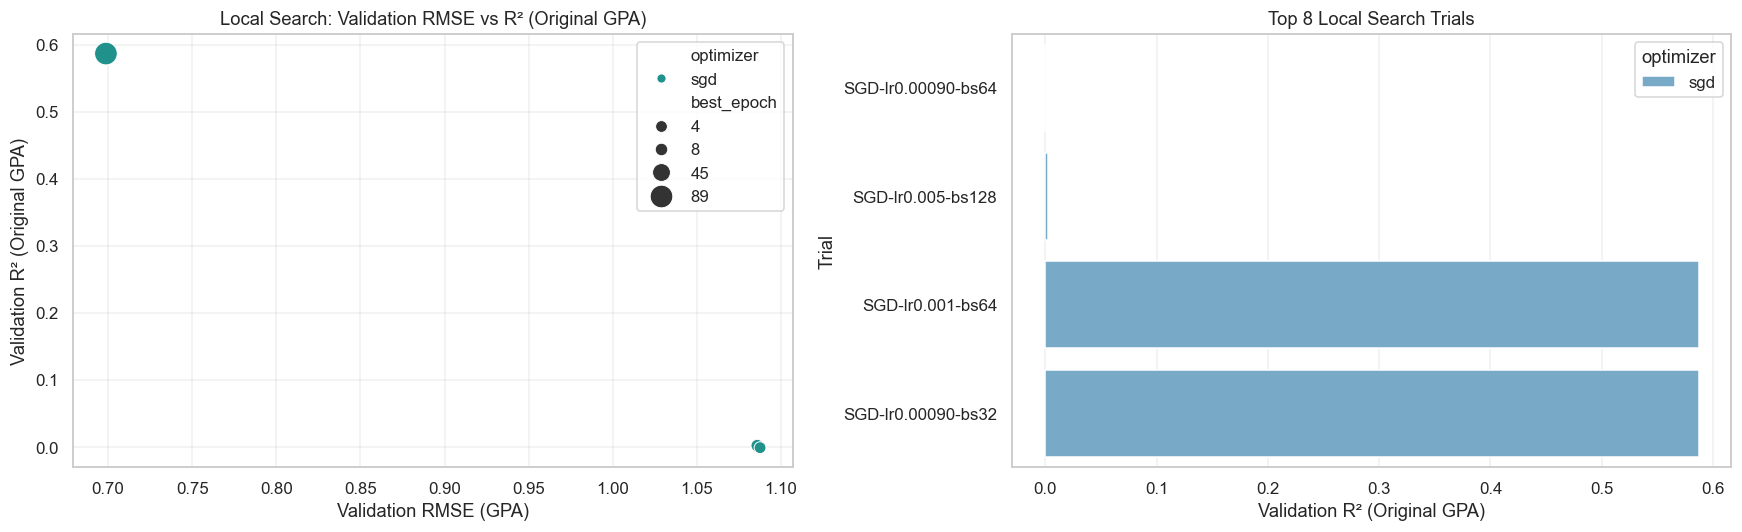

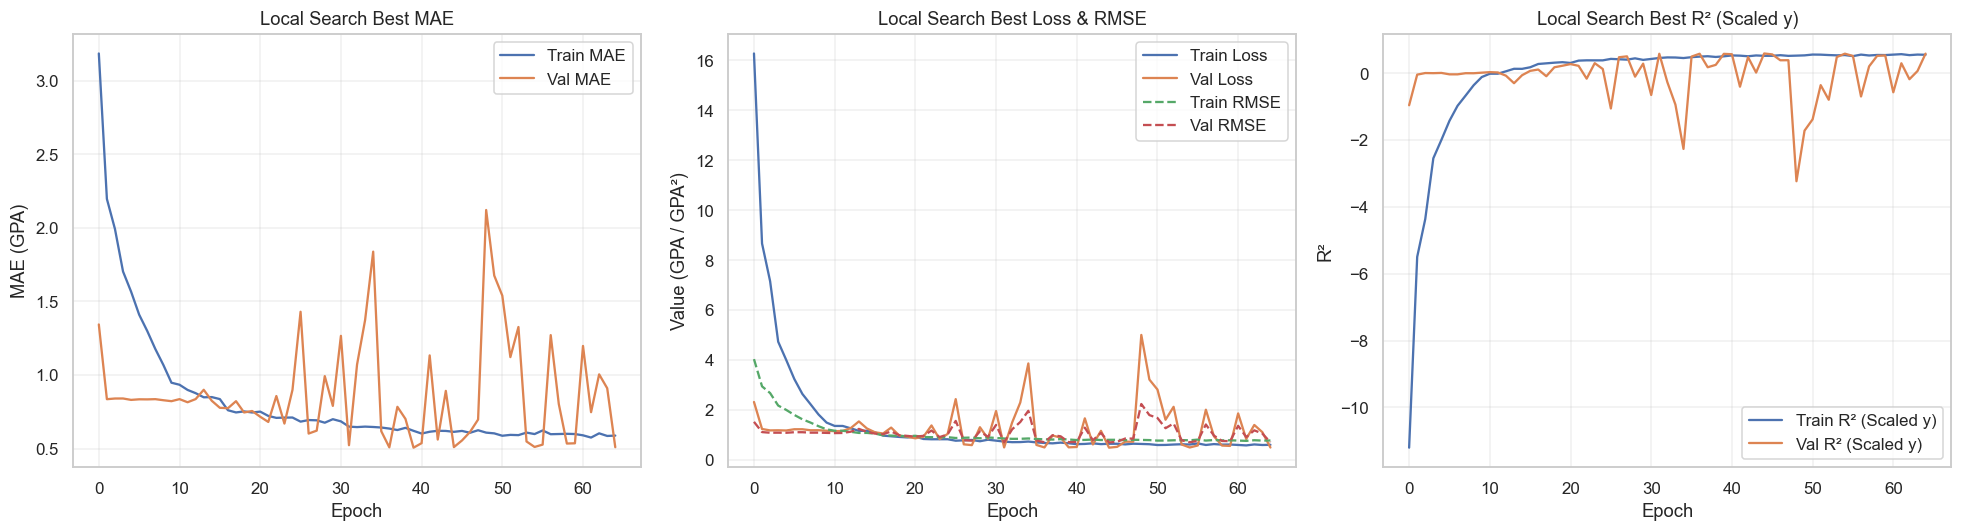


Best Epoch: 45
----------------------------------------
MAE (GPA)   -> Train: 0.6140 | Val: 0.5102
RMSE (GPA)  -> Train: 0.8027 | Val: 0.6986
Loss (GPA²) -> Train: 0.6443 | Val: 0.4881
R² (Scaled y) -> Train: 0.5170 | Val: 0.5870


In [48]:
plot_local_search_summary(local_search_results_df)
if best_local_history is not None:
    plot_regression_history(best_local_history, title_prefix='Local Search Best')

In [49]:
local_val_metrics, local_val_df = evaluate_model_original_scale(
    best_local_model, X_val_lstm, y_val_lstm, scaler, split_name='Local Search Validation'
)
local_test_metrics, local_test_df = evaluate_model_original_scale(
    best_local_model, X_test_lstm, y_test_lstm, scaler, split_name='Local Search Test'
)

local_summary_df = pd.DataFrame([local_val_metrics, local_test_metrics]).set_index('split')
display(format_metrics_display(local_summary_df))
display(local_test_df.head(15))

Local Search Validation RMSE: 0.6986
Local Search Validation MSE:  0.4881
Local Search Validation MAE:              0.5102
Local Search Validation R² (Original GPA): 0.5870
Local Search Validation R² (Scaled y):     0.5870
Local Search Test RMSE: 0.5950
Local Search Test MSE:  0.3541
Local Search Test MAE:              0.4699
Local Search Test R² (Original GPA): 0.6791
Local Search Test R² (Scaled y):     0.6791


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Local Search Validation,0.698611,0.488058,0.510242,0.587021,0.587021
Local Search Test,0.595024,0.354053,0.469933,0.679077,0.679077


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.250000,2.151085,-1.901085,1.901085,3.614124
1,0.000000,1.860216,-1.860216,1.860216,3.460404
2,3.000000,1.291302,1.708698,1.708698,2.919649
3,1.619048,3.284604,-1.665556,1.665556,2.774077
4,2.978261,1.409152,1.569109,1.569109,2.462103
5,0.000000,1.366045,-1.366045,1.366045,1.866078
6,0.000000,1.355899,-1.355899,1.355899,1.838463
7,4.333333,2.978160,1.355173,1.355173,1.836495
8,0.000000,1.344824,-1.344824,1.344824,1.808553
9,0.000000,1.242017,-1.242017,1.242017,1.542607


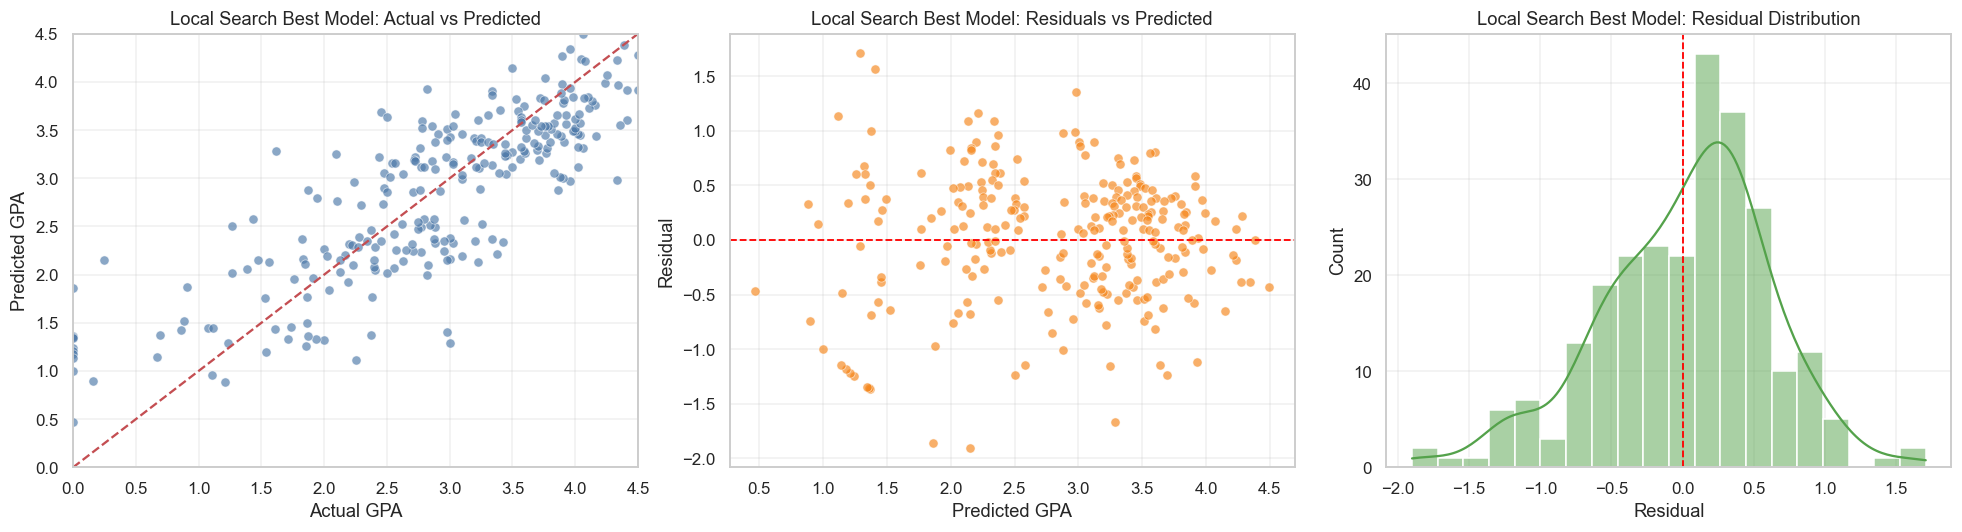

In [50]:
plot_prediction_diagnostics(local_test_df, title_prefix='Local Search Best Model')

### Model Comparison and Grouped Feature Importance

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Baseline,Validation,0.701696,0.492378,0.510639,0.583366,0.583366
1,Baseline,Test,0.649874,0.422337,0.509075,0.617184,0.617184
2,Baseline RNN,Validation,0.694343,0.482112,0.504193,0.592053,0.592053
3,Baseline RNN,Test,0.655885,0.430185,0.503668,0.610070,0.610070
4,Baseline LSTM,Validation,0.682626,0.465978,0.469260,0.605705,0.605705
5,Baseline LSTM,Test,0.574305,0.329826,0.452328,0.701038,0.701038
6,Hyperband Best,Validation,0.683014,0.466508,0.483719,0.605256,0.605256
7,Hyperband Best,Test,0.594830,0.353823,0.447436,0.679286,0.679286
8,Custom,Validation,0.696610,0.485265,0.502330,0.589384,0.589384
9,Custom,Test,0.594918,0.353928,0.465163,0.679191,0.679191


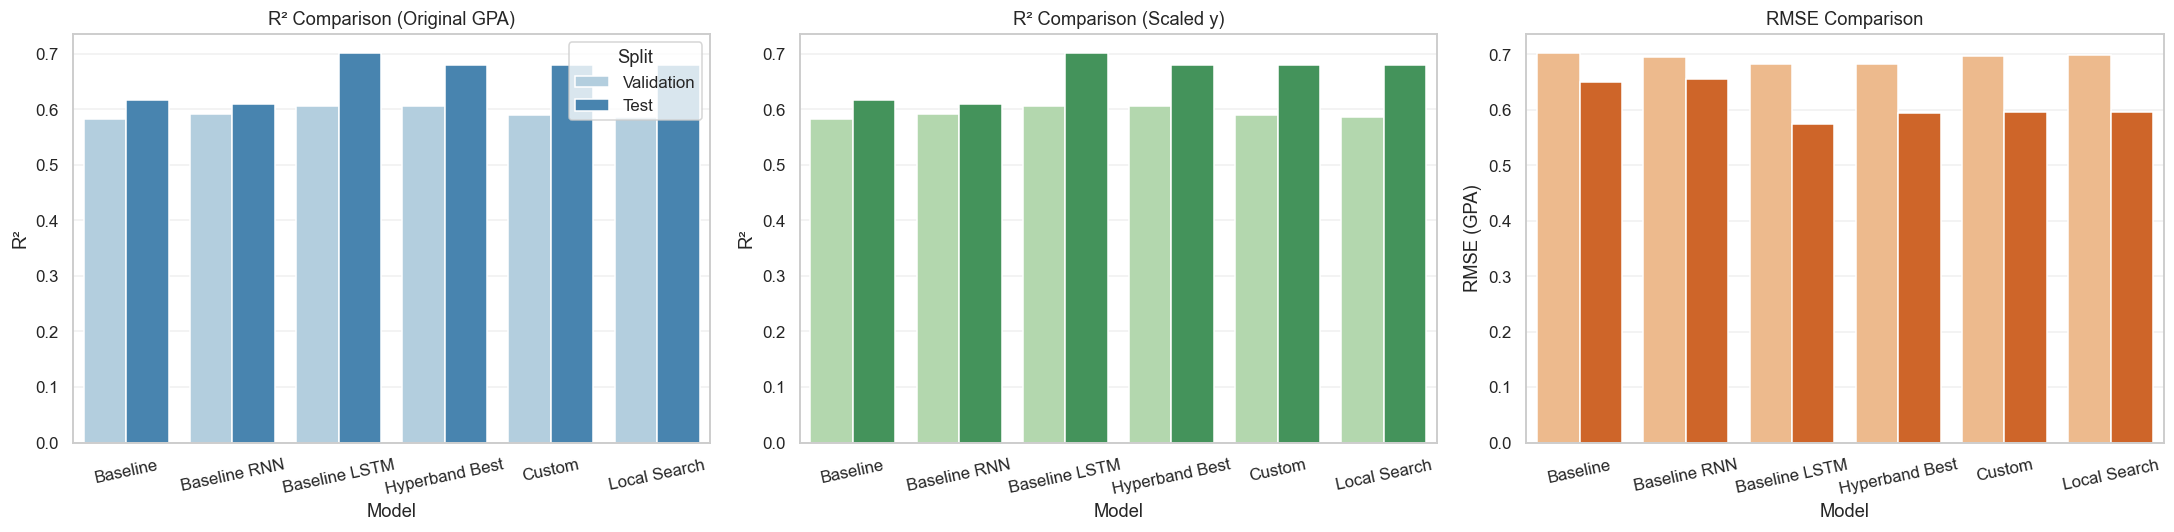

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Baseline LSTM,Test,0.574305,0.329826,0.452328,0.701038,0.701038
1,Hyperband Best,Test,0.594830,0.353823,0.447436,0.679286,0.679286
2,Custom,Test,0.594918,0.353928,0.465163,0.679191,0.679191
3,Local Search,Test,0.595024,0.354053,0.469933,0.679077,0.679077
4,Baseline,Test,0.649874,0.422337,0.509075,0.617184,0.617184
5,Baseline RNN,Test,0.655885,0.430185,0.503668,0.610070,0.610070


In [51]:
# Include every model family already explored in this notebook, not just the final dense/LSTM picks.
experiment_models = {
    'Baseline': baseline_model,
    'Baseline RNN': baseline_rnn,
    'Baseline LSTM': baseline_lstm,
    'Hyperband Best': best_model,
    'Custom': custom_model,
    'Local Search': best_local_model,
}

comparison_rows = [
    ('Baseline', 'Validation', baseline_val_metrics),
    ('Baseline', 'Test', baseline_test_metrics),
    ('Baseline RNN', 'Validation', baseline_rnn_val_metrics),
    ('Baseline RNN', 'Test', baseline_rnn_test_metrics),
    ('Baseline LSTM', 'Validation', baseline_lstm_val_metrics),
    ('Baseline LSTM', 'Test', baseline_lstm_test_metrics),
    ('Hyperband Best', 'Validation', best_val_metrics),
    ('Hyperband Best', 'Test', best_test_metrics),
    ('Custom', 'Validation', custom_val_metrics),
    ('Custom', 'Test', custom_test_metrics),
    ('Local Search', 'Validation', local_val_metrics),
    ('Local Search', 'Test', local_test_metrics),
]

comparison_df = pd.DataFrame([
    {
        'Model': model_name,
        'Split': split_name,
        **{k: v for k, v in metrics.items() if k != 'split'},
    }
    for model_name, split_name, metrics in comparison_rows
])

model_order = list(experiment_models.keys())
split_order = ['Validation', 'Test']
comparison_df['Model'] = pd.Categorical(comparison_df['Model'], categories=model_order, ordered=True)
comparison_df['Split'] = pd.Categorical(comparison_df['Split'], categories=split_order, ordered=True)
comparison_df = comparison_df.sort_values(['Model', 'Split']).reset_index(drop=True)

display(format_metrics_display(comparison_df))
plot_experiment_comparison(comparison_df)

test_rank_df = comparison_df[comparison_df['Split'] == 'Test'].sort_values(['r2_original', 'rmse'], ascending=[False, True]).reset_index(drop=True)
display(format_metrics_display(test_rank_df))

In [52]:
# export test predictions of the best model to csv for error analysis
best_test_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'second_term_best_model_test_predictions.csv',
    index=False,
)

Selected model for grouped feature importance: Baseline LSTM


,Feature Group,RMSE Increase (Mean),RMSE Increase (Std),R² Drop (Mean),Grouped Columns
0,gpa_category,0.106903,0.006486,0.121696,"gpa_category_0, gpa_category_1, gpa_category_2..."
1,first_term_gpa,0.102859,0.011567,0.116800,"first_term_gpa, first_term_gpa_sq"
2,gpa_math_interaction,0.065542,0.007950,0.072189,gpa_math_interaction
3,gpa_english_interaction,0.065539,0.002968,0.072135,gpa_english_interaction
4,gpa_hs_interaction,0.058419,0.013139,0.064072,gpa_hs_interaction
5,first_term_gpa_sq,0.046853,0.006007,0.050802,first_term_gpa_sq
6,preparedness_gap,0.033918,0.004737,0.036376,preparedness_gap
7,hs_math_interaction,0.024180,0.011036,0.025815,hs_math_interaction
8,math_score,0.014335,0.002643,0.015118,math_score
9,hs_math_gap,0.012467,0.005540,0.013148,hs_math_gap


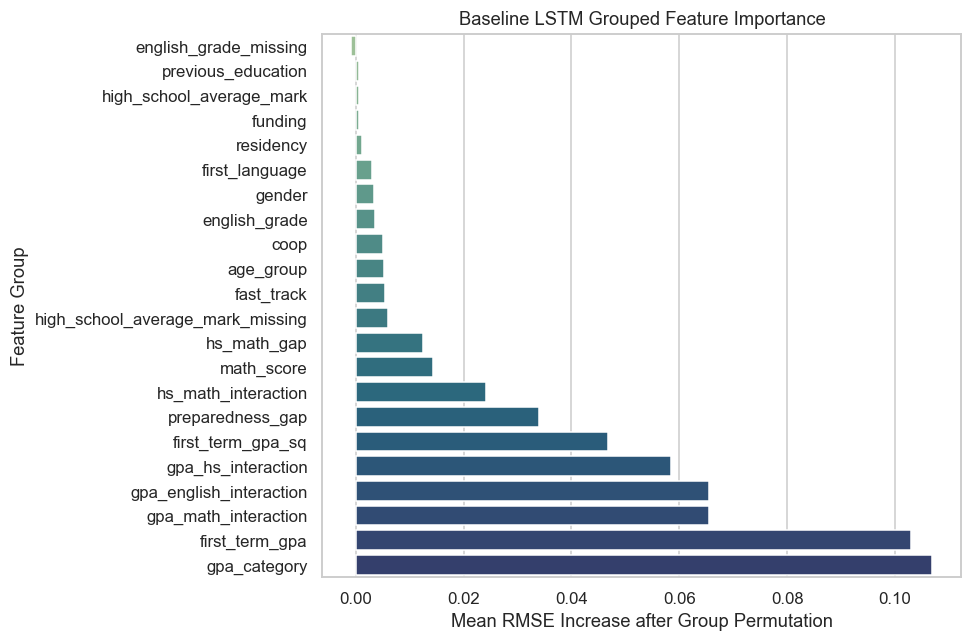

In [53]:
selected_model_name = test_rank_df.iloc[0]['Model']
selected_model = experiment_models[selected_model_name]
print(f'Selected model for grouped feature importance: {selected_model_name}')

grouped_importance_df = compute_grouped_permutation_importance(
    selected_model,
    X_test,
    y_test,
    scaler,
    n_repeats=3,
    random_state=42,
)

display(grouped_importance_df)
plot_grouped_feature_importance(
    grouped_importance_df,
    title=f'{selected_model_name} Grouped Feature Importance',
)

### Experiment 6: Relay Modeling to Predict Third Term GPA

In [54]:
# check the nan values in first_term_gpa and second_term_gpa columns
clean_df["first_term_gpa"] = clean_df["first_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")

print(f"Number of rows with nulls in first_term_gpa: {clean_df['first_term_gpa'].isna().sum()}")
print(f"Number of rows with nulls in second_term_gpa: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
clean_df = clean_df.dropna(subset=["first_term_gpa"])
print(f"Number of rows after dropping nulls in both first and second term GPA variables: {clean_df.shape[0]}")

Number of rows with nulls in first_term_gpa: 0
Number of rows with nulls in second_term_gpa: 0
Number of rows after dropping nulls in both first and second term GPA variables: 1277


In [55]:
clean_df.head()

,first_term_gpa,second_term_gpa,first_language,funding,school,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence
0,0.000000,0.000000,1,2.0,6.0,2.0,1.0,1.0,2.0,1,1,59,16,7,1.0
1,2.500000,2.000000,3,4.0,6.0,1.0,2.0,2.0,2.0,1,3,?,?,7,1.0
2,4.250000,3.923077,1,1.0,6.0,2.0,1.0,1.0,1.0,2,3,92,41,9,1.0
3,3.020833,2.321429,3,4.0,6.0,1.0,2.0,2.0,2.0,2,3,?,?,8,1.0
4,4.275000,4.326923,1,2.0,6.0,1.0,1.0,1.0,1.0,2,3,97,?,9,1.0


In [56]:
# Synthetic proxy for third-term GPA (relay model):
# Weighted progression from first- and second-term GPA,
# conditioned on first-year persistence (non-persistent students assigned 0)
clean_df["third_term_gpa_proxy"] = (
    0.6 * clean_df["second_term_gpa"] + 0.4 * clean_df["first_term_gpa"]
) * clean_df["first_year_persistence"]

# Feature and target separation
y_new = clean_df["third_term_gpa_proxy"] # third_term_gpa_proxy 
X_new = clean_df.drop(columns=["school", "third_term_gpa_proxy"]) # Drop school - unique value

In [57]:
# Replace second_term_gpa with predictions from the best model
# to create a fully synthetic dataset for third-term GPA prediction

# Preprocess new input data
X_new_features = cleaner.transform(
    X_new.drop(columns=["second_term_gpa", "first_year_persistence"])
)

# Scale actual second_term_gpa for comparison
y_new_scaled = scaler.transform(
    X_new["second_term_gpa"].values.reshape(-1, 1)
).flatten()

X_new_lstm = np.asarray(X_new_features).astype(np.float32).reshape(X_new_features.shape[0], X_new_features.shape[1], 1)

# Evaluate best model on test set
best_test_metrics, predicted_df = evaluate_model_original_scale(
    best_model,
    X_new_lstm,
    y_new_scaled,
    scaler,
    split_name="Hyperband Test"
)

display(predicted_df.head(15))

#save results to csv
predicted_df.to_csv(
project_path / 'second_term_gpa_regression' / 'trial_results' / 'third_term_gpa_proxy_predictions.csv',
    index=False,
)

Hyperband Test RMSE: 0.6687
Hyperband Test MSE:  0.4472
Hyperband Test MAE:              0.4864
Hyperband Test R² (Original GPA): 0.6486
Hyperband Test R² (Scaled y):     0.6486


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,3.415859,-3.415859,3.415859,11.668093
1,0.136364,3.385211,-3.248847,3.248847,10.555007
2,1.022727,3.932053,-2.909326,2.909326,8.464178
3,3.700000,1.038674,2.661326,2.661326,7.082656
4,0.000000,2.326906,-2.326906,2.326906,5.414490
5,0.000000,2.301641,-2.301641,2.301641,5.297549
6,0.000000,2.259140,-2.259140,2.259140,5.103714
7,0.000000,2.082376,-2.082376,2.082376,4.336289
8,0.300000,2.351121,-2.051121,2.051121,4.207096
9,0.000000,2.048172,-2.048172,2.048172,4.195009


In [58]:
X_new["predicted_second_term_gpa"] = predicted_df["Predicted GPA"].values
X_new.head()

,first_term_gpa,second_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,predicted_second_term_gpa
0,0.000000,0.000000,1,2.0,2.0,1.0,1.0,2.0,1,1,59,16,7,1.0,3.415859
1,2.500000,2.000000,3,4.0,1.0,2.0,2.0,2.0,1,3,?,?,7,1.0,3.385211
2,4.250000,3.923077,1,1.0,2.0,1.0,1.0,1.0,2,3,92,41,9,1.0,3.932053
3,3.020833,2.321429,3,4.0,1.0,2.0,2.0,2.0,2,3,?,?,8,1.0,1.038674
4,4.275000,4.326923,1,2.0,1.0,1.0,1.0,1.0,2,3,97,?,9,1.0,2.326906


In [59]:
# Drop original column
X_new = X_new.drop(columns=["second_term_gpa"])

# Rename predicted → official column
if "predicted_second_term_gpa" in X_new.columns:
    X_new = X_new.rename(
        columns={"predicted_second_term_gpa": "second_term_gpa"}
    )

X_new.head()

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,second_term_gpa
0,0.000000,1,2.0,2.0,1.0,1.0,2.0,1,1,59,16,7,1.0,3.415859
1,2.500000,3,4.0,1.0,2.0,2.0,2.0,1,3,?,?,7,1.0,3.385211
2,4.250000,1,1.0,2.0,1.0,1.0,1.0,2,3,92,41,9,1.0,3.932053
3,3.020833,3,4.0,1.0,2.0,2.0,2.0,2,3,?,?,8,1.0,1.038674
4,4.275000,1,2.0,1.0,1.0,1.0,1.0,2,3,97,?,9,1.0,2.326906


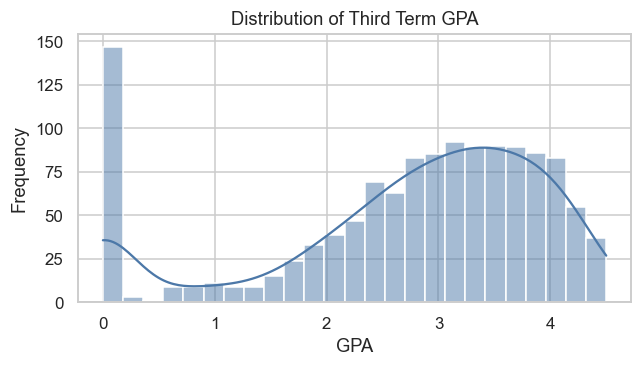

In [60]:
# check target variable distribution

plt.figure(figsize=(6,3.5))

sns.histplot(y_new, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Third Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [61]:
# test-train split with stratification and train-only feature fitting
X_new_train_raw, X_new_test, y_new_train, y_new_test = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
)

X_new_train, X_new_val, y_new_train, y_new_val = train_test_split(
    X_new_train_raw,
    y_new_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_new_train: {X_new_train.shape}, X_new_val: {X_new_val.shape}, X_new_test: {X_new_test.shape}")

X_new_train: (893, 14), X_new_val: (128, 14), X_new_test: (256, 14)


In [62]:
# check the final training dataset
display(X_new_train.head())

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,second_term_gpa
78,3.521739,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7,1.0,3.390189
353,2.250000,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7,1.0,2.688449
1354,3.400000,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8,1.0,2.962190
510,4.214286,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9,1.0,3.696528
338,2.547619,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9,0.0,2.411327


### Data Cleaning

In [63]:
# Data cleaning

from second_term_gpa_regression.utils.data_cleaner_proxy import DataCleaner

cleaner_2 = DataCleaner(numeric_imputer="bayesian")

X_new_train = cleaner_2.fit_transform(X_new_train)
X_new_val = cleaner_2.transform(X_new_val)
X_new_test = cleaner_2.transform(X_new_test)

# Target standardization
scaler_2 = MinMaxScaler()
y_new_train = scaler_2.fit_transform(y_new_train.values.reshape(-1, 1)).flatten()
y_new_val = scaler_2.transform(y_new_val.values.reshape(-1, 1)).flatten()
y_new_test = scaler_2.transform(y_new_test.values.reshape(-1, 1)).flatten()

In [64]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner_2, project_path / "second_term_gpa_regression" / "models" / 'best_second_term_regression_model' / "relay_third_term_preprocessing_pipeline.pkl")
joblib.dump(scaler_2, project_path / "second_term_gpa_regression" / "models" / 'best_second_term_regression_model' / "relay_third_term_target_scaler.pkl")

# check the training after cleaning
display(X_new_train.head())

,first_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,second_term_gpa,...,funding_9,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3,gpa_category_1,gpa_category_2,gpa_category_3
78,0.486738,1,0,0,3.0,0.396477,0.250102,7.0,1.0,0.593069,...,False,True,False,False,True,False,False,False,False,True
353,-0.764013,0,0,1,2.0,0.268027,0.140491,7.0,1.0,-0.228940,...,False,False,True,False,False,True,False,False,True,False
1354,0.367008,1,0,0,4.0,0.261638,0.188562,8.0,1.0,0.091716,...,False,True,False,False,False,True,False,False,False,True
510,1.167855,0,1,1,4.0,-0.752545,1.665523,9.0,1.0,0.951911,...,False,False,True,False,False,True,False,False,False,True
338,-0.471306,0,1,1,2.0,-0.242259,-0.705309,9.0,0.0,-0.553557,...,False,False,True,False,True,False,False,False,True,False


In [65]:
baseline_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2},
]

baseline_model = build_dense_model(X_new_train.shape[1], baseline_layers)
baseline_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 516)                 │          17,028 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 516)                 │           2,064 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 516)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          66,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 85,909 (335.58 KB)

 Trainable params: 84,621 (330.55 KB)

 Non-trainable params: 1,288 (5.03 KB)

In [66]:
baseline_model = compile_regression_model(baseline_model, optimizer_name='sgd', learning_rate=0.0009)

baseline_es, baseline_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_second_term_regression_model' / 'relay_third_term_regression_ann_model.keras')

history_baseline = baseline_model.fit(
    X_new_train, y_new_train,
    validation_data=(X_new_val, y_new_val),
    epochs=200,
    batch_size=32,
    callbacks=[baseline_es, baseline_mc],
    verbose=1,
)

Epoch 1/200
25/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.9571 - mae: 1.0629 - r2: -21.3817 - rmse: 1.3854
Epoch 1: val_loss improved from None to 0.14583, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_second_term_regression_model\relay_third_term_regression_ann_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_second_term_regression_model\relay_third_term_regression_ann_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 1.2615 - mae: 0.8563 - r2: -14.3145 - rmse: 1.1232 - val_loss: 0.1458 - val_mae: 0.3359 - val_r2: -0.8502 - val_rmse: 0.3819
Epoch 2/200
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6632 - mae: 0.6319 - r2: -6.9877 - rmse: 0.8104
Epoch 2: val_loss improved from 0.14583 to 0.07564, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neura

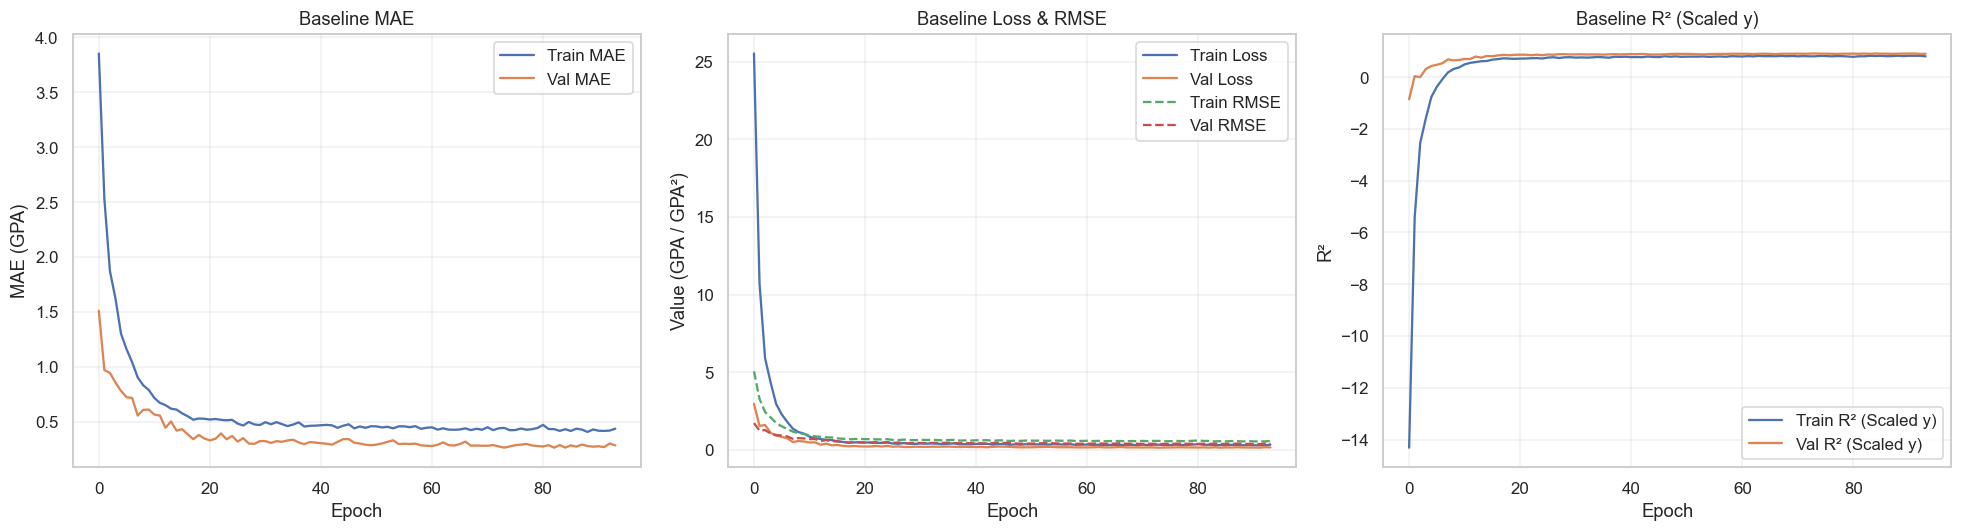


Best Epoch: 74
----------------------------------------
MAE (GPA)   -> Train: 0.4454 | Val: 0.2654
RMSE (GPA)  -> Train: 0.5688 | Val: 0.3643
Loss (GPA²) -> Train: 0.3235 | Val: 0.1327
R² (Scaled y) -> Train: 0.8060 | Val: 0.9168


In [67]:
plot_regression_history(history_baseline, title_prefix='Baseline')

In [68]:
baseline_val_metrics, baseline_val_df = evaluate_model_original_scale(
    baseline_model, X_new_val, y_new_val, scaler, split_name='Baseline Validation'
)
baseline_test_metrics, baseline_test_df = evaluate_model_original_scale(
    baseline_model, X_new_test, y_new_test, scaler, split_name='Baseline Test'
)

baseline_summary_df = pd.DataFrame([baseline_val_metrics, baseline_test_metrics]).set_index('split')
display(format_metrics_display(baseline_summary_df))
display(baseline_test_df.head(15))


Baseline Validation RMSE: 0.3643
Baseline Validation MSE:  0.1327
Baseline Validation MAE:              0.2654
Baseline Validation R² (Original GPA): 0.9168
Baseline Validation R² (Scaled y):     0.9168
Baseline Test RMSE: 0.3753
Baseline Test MSE:  0.1408
Baseline Test MAE:              0.2809
Baseline Test R² (Original GPA): 0.9030
Baseline Test R² (Scaled y):     0.9030


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline Validation,0.364328,0.132735,0.265401,0.916837,0.916837
Baseline Test,0.375270,0.140827,0.280899,0.902965,0.902965


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,1.572040,-1.572040,1.572040,2.471309
1,0.542784,1.821924,-1.279141,1.279141,1.636201
2,0.932053,2.154963,-1.222911,1.222911,1.495510
3,0.218512,1.399447,-1.180935,1.180935,1.394607
4,0.000000,1.087525,-1.087525,1.087525,1.182711
5,0.430781,1.445363,-1.014582,1.014582,1.029376
6,0.794072,1.770529,-0.976457,0.976457,0.953468
7,1.175074,2.139932,-0.964859,0.964859,0.930952
8,0.000000,0.916585,-0.916585,0.916585,0.840128
9,2.766985,1.860413,0.906571,0.906571,0.821872


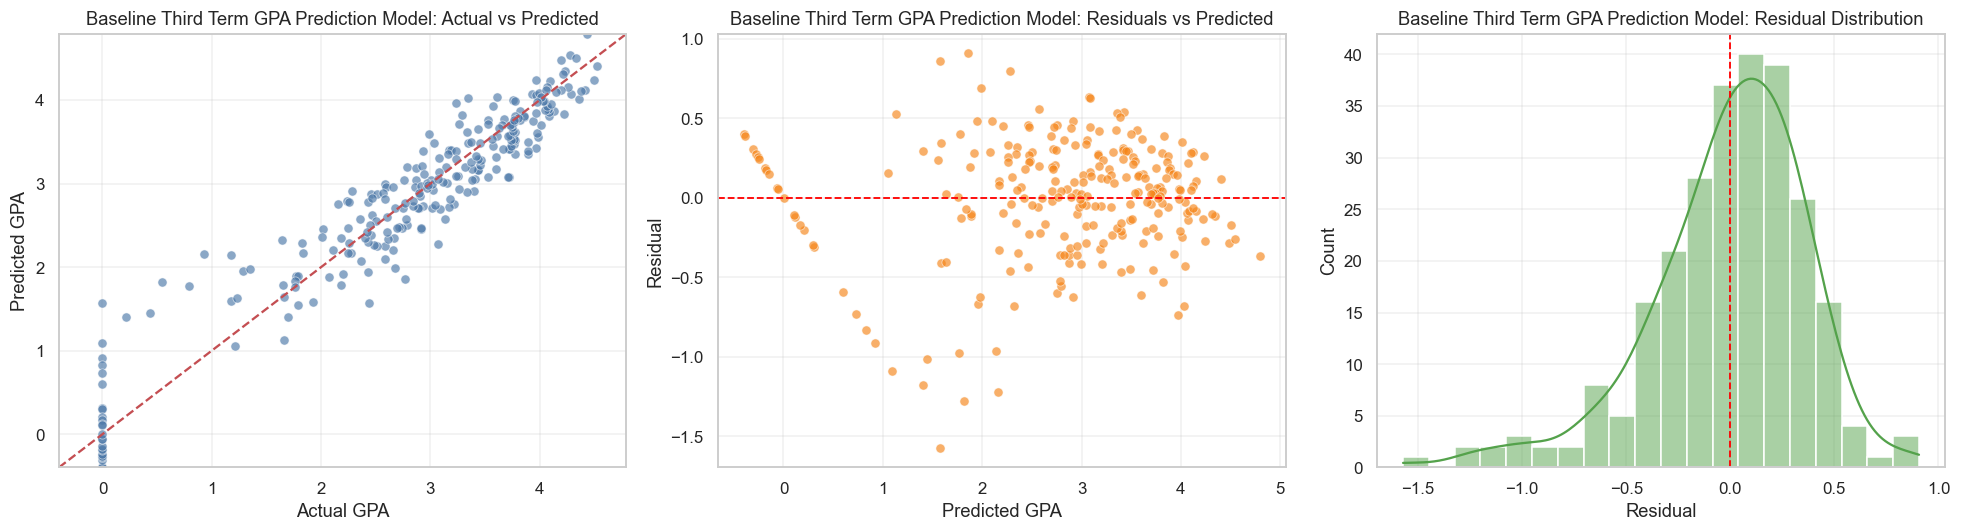

In [69]:
plot_prediction_diagnostics(baseline_test_df, title_prefix='Baseline Third Term GPA Prediction Model')

,Feature Group,RMSE Increase (Mean),RMSE Increase (Std),R² Drop (Mean),Grouped Columns
0,first_term_gpa,0.624261,0.012731,0.595905,first_term_gpa
1,first_year_persistence,0.595510,0.021404,0.556751,first_year_persistence
2,funding,0.039108,0.004137,0.021405,"funding_1, funding_2, funding_4, funding_5, fu..."
3,high_school_average_mark,0.019795,0.008628,0.010614,high_school_average_mark
4,first_language,0.009504,0.002830,0.005009,"first_language_0, first_language_1, first_lang..."
5,age_group,0.009166,0.008656,0.004875,age_group
6,english_grade,0.006739,0.001027,0.003535,english_grade
7,gpa_category,0.006660,0.001576,0.003495,"gpa_category_1, gpa_category_2, gpa_category_3"
8,residency,0.003635,0.001242,0.001900,residency
9,gender,0.003532,0.001193,0.001846,"gender_1, gender_2"


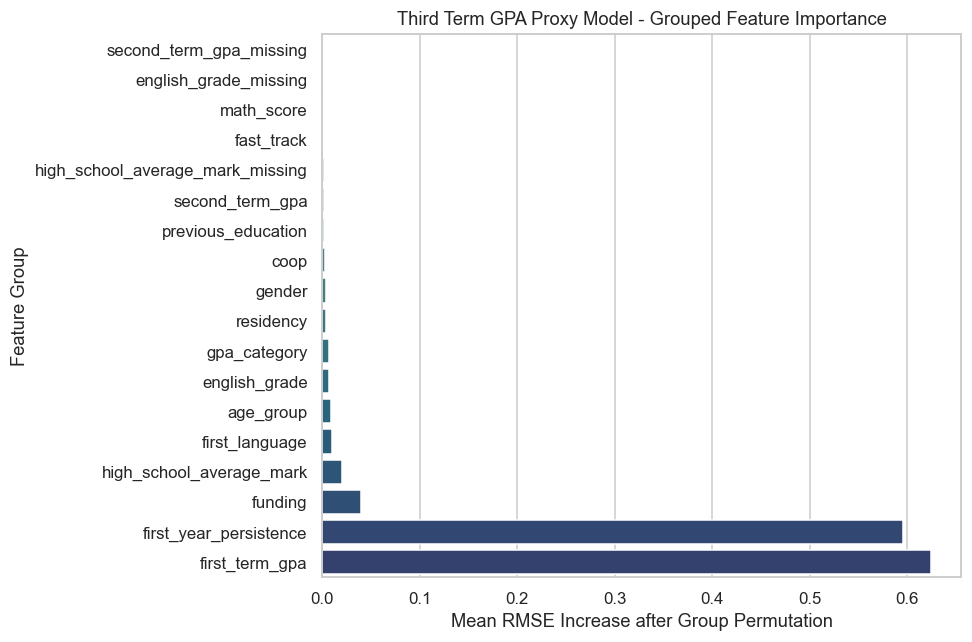

In [70]:
proxy_grouped_importance_df = compute_proxy_grouped_permutation_importance(
    baseline_model,
    X_new_test,
    y_new_test,
    scaler_2,
    n_repeats=3,
    random_state=42,
)

display(proxy_grouped_importance_df)
plot_grouped_feature_importance(
    proxy_grouped_importance_df,
    title='Third Term GPA Proxy Model - Grouped Feature Importance',
)